In [22]:
# @title 1. Install Dependencies and Setup (Check for Model First)
!pip install -q torch torchvision pandas numpy pillow matplotlib scikit-learn opencv-python albumentations gdown

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import cv2
import os
import glob
from sklearn.model_selection import train_test_split
import json
import albumentations as A
from albumentations.pytorch import ToTensorV2
import gdown
import shutil

# ============================================================
# PATHS
# ============================================================
EXTRACT_PATH = "/content/combined"
OUTPUT_PATH = "/content/geez_crnn_model"
SHARED_FOLDER_ID = "1Bn-cg_t4YR-HbOduP0_y_xBV-aEQ93K_"
os.makedirs(EXTRACT_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("=" * 60)
print("GEEZ SCRIPT RECOGNITION - CRNN WITH PREPROCESSING")
print("=" * 60)

# ============================================================
# FIRST: TRY TO DOWNLOAD EXISTING MODEL FROM SHARED DRIVE
# ============================================================
print("\n🔍 CHECKING FOR EXISTING MODEL IN SHARED DRIVE...")
print(f"   Source: https://drive.google.com/drive/folders/{SHARED_FOLDER_ID}")

model_downloaded = False

# Check if model already exists locally
if os.path.exists(f"{OUTPUT_PATH}/best_model.pth"):
    print("✅ Model already exists locally! Will use existing model.")
    model_downloaded = True
else:
    # Try to download model from shared drive
    print("📥 Attempting to download model from shared drive...")
    try:
        temp_dir = "/content/temp_model"
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
        os.makedirs(temp_dir, exist_ok=True)

        # Download the folder
        !gdown --folder "https://drive.google.com/drive/folders/{SHARED_FOLDER_ID}" -O {temp_dir} --remaining-ok 2>&1

        # Search for model files (compatible with Cell 11 save format)
        for root, dirs, files in os.walk(temp_dir):
            for file in files:
                # Look for best_model.pth
                if file == "best_model.pth":
                    src = os.path.join(root, file)
                    dst = os.path.join(OUTPUT_PATH, file)
                    shutil.copy2(src, dst)
                    print(f"✅ Found and copied: {file}")

                # Look for mapping files (Cell 11 saves these formats)
                elif file in ["char_to_idx.json", "idx_to_char.json", "model_config.json", "model_info.json"]:
                    src = os.path.join(root, file)
                    dst = os.path.join(OUTPUT_PATH, file)
                    shutil.copy2(src, dst)
                    print(f"✅ Found mapping: {file}")

                # Also check for char_mappings.json in checkpoints folder
                elif file == "char_mappings.json":
                    src = os.path.join(root, file)
                    dst = os.path.join(OUTPUT_PATH, "char_mappings.json")
                    shutil.copy2(src, dst)
                    print(f"✅ Found mapping: {file}")

                # Look for checkpoints directory contents
                elif file.startswith("checkpoint_epoch_") and file.endswith(".pth"):
                    # Ensure checkpoints directory exists
                    checkpoints_dir = os.path.join(OUTPUT_PATH, "checkpoints")
                    os.makedirs(checkpoints_dir, exist_ok=True)
                    src = os.path.join(root, file)
                    dst = os.path.join(checkpoints_dir, file)
                    shutil.copy2(src, dst)
                    print(f"✅ Found checkpoint: {file}")

        if os.path.exists(f"{OUTPUT_PATH}/best_model.pth"):
            model_downloaded = True
            print("✅ Model successfully downloaded from shared drive!")

            # Verify we have the necessary mapping files
            required_files = ["best_model.pth"]
            missing_files = [f for f in required_files if not os.path.exists(f"{OUTPUT_PATH}/{f}")]

            if missing_files:
                print(f"⚠️ Missing files: {missing_files}")
            else:
                print("✅ All required model files present:")
                for f in os.listdir(OUTPUT_PATH):
                    if f.endswith('.pth') or f.endswith('.json'):
                        print(f"   - {f}")
        else:
            print("⚠️ No model files found in shared drive.")

    except Exception as e:
        print(f"Download failed: {e}")

USE_EXISTING_MODEL = model_downloaded

# ============================================================
# IF MODEL EXISTS: SKIP DATASET DOWNLOAD AND TRAINING
# ============================================================
if USE_EXISTING_MODEL:
    print("\n" + "=" * 60)
    print("✅ MODEL FOUND! Skipping dataset download and training.")
    print("   Model is ready for testing/inference.")
    print("=" * 60)

    # Display model files
    print("\n📁 Model files:")
    !ls -la "{OUTPUT_PATH}"

    # Try to load character mappings from downloaded files
    print("\n📚 Loading character mappings...")

    # Try different mapping file formats
    mappings_loaded = False

    # Try separate files first (Cell 11 format)
    if os.path.exists(f"{OUTPUT_PATH}/char_to_idx.json") and os.path.exists(f"{OUTPUT_PATH}/idx_to_char.json"):
        with open(f"{OUTPUT_PATH}/char_to_idx.json", 'r', encoding='utf-8') as f:
            char_to_idx = json.load(f)
        with open(f"{OUTPUT_PATH}/idx_to_char.json", 'r', encoding='utf-8') as f:
            idx_to_char_raw = json.load(f)
            idx_to_char = {int(k): v for k, v in idx_to_char_raw.items()}
        num_classes = len(char_to_idx) + 1  # +1 for blank
        mappings_loaded = True
        print(f"✅ Loaded mappings from separate files: {num_classes} classes")

    # Try combined mappings file
    elif os.path.exists(f"{OUTPUT_PATH}/char_mappings.json"):
        with open(f"{OUTPUT_PATH}/char_mappings.json", 'r', encoding='utf-8') as f:
            mappings = json.load(f)
            char_to_idx = mappings['char_to_idx']
            idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
            num_classes = mappings['num_classes']
        mappings_loaded = True
        print(f"✅ Loaded mappings from combined file: {num_classes} classes")

    # Try checkpoints directory
    elif os.path.exists(f"{OUTPUT_PATH}/checkpoints/char_mappings.json"):
        with open(f"{OUTPUT_PATH}/checkpoints/char_mappings.json", 'r', encoding='utf-8') as f:
            mappings = json.load(f)
            char_to_idx = mappings['char_to_idx']
            idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
            num_classes = mappings['num_classes']
        mappings_loaded = True
        print(f"✅ Loaded mappings from checkpoints: {num_classes} classes")

    if not mappings_loaded:
        print("⚠️ No character mappings found. Will create from dataset if needed.")
        char_to_idx = None
        idx_to_char = None
        num_classes = None

else:
    # ============================================================
    # NO MODEL FOUND: DOWNLOAD DATASET FOR TRAINING
    # ============================================================
    print("\n" + "=" * 60)
    print("⚠️ NO EXISTING MODEL FOUND. Downloading dataset for training...")
    print("=" * 60)

    FILE_ID = "1T1Y9xVDRndpLRb1JtO-OXaSLCLQ11DJ6"
    RAR_FILE = f"{EXTRACT_PATH}/combined.rar"

    if os.path.exists(RAR_FILE):
        file_size_mb = os.path.getsize(RAR_FILE) / (1024 * 1024)
        print(f"✅ RAR file already exists: {RAR_FILE} ({file_size_mb:.2f} MB)")
    else:
        print("📥 Downloading dataset from Google Drive (this may take several minutes)...")
        print(f"   Source: https://drive.google.com/file/d/{FILE_ID}/view")
        url = f"https://drive.google.com/uc?id={FILE_ID}"
        gdown.download(url, RAR_FILE, quiet=False)

        if os.path.exists(RAR_FILE):
            file_size_mb = os.path.getsize(RAR_FILE) / (1024 * 1024)
            print(f"✅ Download complete! File size: {file_size_mb:.2f} MB")
        else:
            raise FileNotFoundError("❌ Download failed. Please check the link and sharing permissions.")

    # Extract the RAR file
    if os.path.exists(f"{EXTRACT_PATH}/combined") and len(os.listdir(f"{EXTRACT_PATH}/combined")) > 100:
        print(f"✅ Dataset already extracted at: {EXTRACT_PATH}/combined")
    else:
        !apt-get install -y unrar -qq 2>/dev/null
        print("✅ unrar ready")
        print("📂 Extracting dataset...")
        !unrar x -o+ "{RAR_FILE}" "{EXTRACT_PATH}/" > /dev/null 2>&1
        print("✅ Extraction complete!")

    # Verify the extracted dataset
    DATASET_PATH = f"{EXTRACT_PATH}/combined"
    if os.path.exists(DATASET_PATH):
        png_files = glob.glob(f"{DATASET_PATH}/*.png")
        gt_files = glob.glob(f"{DATASET_PATH}/*.gt.txt")
        print(f"\n📊 Dataset verification:")
        print(f"   Location: {DATASET_PATH}")
        print(f"   PNG images found: {len(png_files)}")
        print(f"   Ground truth files found: {len(gt_files)}")
        if png_files:
            print(f"   Sample image: {png_files[0]}")
        if gt_files:
            with open(gt_files[0], 'r', encoding='utf-8') as f:
                sample_text = f.read().strip()[:80]
            print(f"   Sample ground truth: {sample_text}...")
    else:
        print(f"❌ Error: Expected dataset folder not found at {DATASET_PATH}")

    # Initialize empty mappings (will be created during training)
    char_to_idx = None
    idx_to_char = None
    num_classes = None

print("\n" + "=" * 60)
if USE_EXISTING_MODEL:
    print("✅ Setup complete! Model is ready for testing.")
    print("   You can skip training cells and go directly to testing.")
else:
    print("✅ Setup complete! Dataset is ready for training.")
    print("   You can now run the remaining training cells.")
print("=" * 60)

GEEZ SCRIPT RECOGNITION - CRNN WITH PREPROCESSING

🔍 CHECKING FOR EXISTING MODEL IN SHARED DRIVE...
   Source: https://drive.google.com/drive/folders/1Bn-cg_t4YR-HbOduP0_y_xBV-aEQ93K_
✅ Model already exists locally! Will use existing model.

✅ MODEL FOUND! Skipping dataset download and training.
   Model is ready for testing/inference.

📁 Model files:
total 104064
drwxr-xr-x 3 root root      4096 Apr 24 08:40 .
drwxr-xr-x 1 root root      4096 Apr 24 08:57 ..
-rw-r--r-- 1 root root 106476782 Apr 24 08:16 best_model.pth
-rw-r--r-- 1 root root      4222 Apr 24 08:40 char_to_idx.json
drwxr-xr-x 2 root root      4096 Apr 24 08:40 checkpoints
-rw-r--r-- 1 root root      4856 Apr 24 08:40 idx_to_char.json
-rw-r--r-- 1 root root        90 Apr 24 08:40 model_config.json
-rw-r--r-- 1 root root       549 Apr 24 08:40 model_info.json
-rw-r--r-- 1 root root     39749 Apr 24 08:40 training_curves.png
-rw-r--r-- 1 root root      2133 Apr 24 08:40 training_history.json

📚 Loading character mappings..

In [23]:
# @title Create symlink so both paths work (Only if training needed)
import os
import glob

# Only create symlink if we need to train (no existing model)
if not USE_EXISTING_MODEL:
    # The dataset is actually extracted to /content/combined/combined from Cell 1
    ACTUAL_DATASET_PATH = "/content/combined/combined"
    SYMLINK_PATH = "/content/combined"

    # Check if the actual dataset exists
    if os.path.exists(ACTUAL_DATASET_PATH):
        # Create symlink if it doesn't exist
        if not os.path.exists(SYMLINK_PATH):
            os.symlink(ACTUAL_DATASET_PATH, SYMLINK_PATH)
            print(f"✅ Created symlink: {SYMLINK_PATH} -> {ACTUAL_DATASET_PATH}")
        else:
            print(f"✅ {SYMLINK_PATH} already exists")
    else:
        print(f"⚠️ Dataset not found at {ACTUAL_DATASET_PATH}")
        print("   Dataset may be in a different location")

    # Verify
    if os.path.exists("/content/combined"):
        files = os.listdir("/content/combined")
        print(f"📁 /content/combined contains {len(files)} files/directories")

        # Count images
        images = glob.glob("/content/combined/**/*.png", recursive=True)
        print(f"📸 Found {len(images)} images")
    else:
        print("❌ /content/combined not found - dataset may not be extracted yet")
else:
    print("✅ Using existing model - skipping symlink creation (no dataset needed)")

✅ Using existing model - skipping symlink creation (no dataset needed)


In [24]:
# @title 2. Extract RAR File (Always extract for dataset access)
import glob
import os

print("Extracting dataset...")
print("=" * 60)

# Define paths (matching Cell 1)
if 'RAR_FILE' not in dir():
    RAR_FILE = "/content/combined/combined.rar"  # Fixed: RAR is inside /content/combined/
if 'EXTRACT_PATH' not in dir():
    EXTRACT_PATH = "/content/combined"

# Install unrar
!apt-get install -y unrar -qq 2>/dev/null
print("✅ unrar ready")

# Extract the RAR file
if os.path.exists(RAR_FILE):
    print(f"📦 Found RAR file: {RAR_FILE}")
    !unrar x -o+ "{RAR_FILE}" "{EXTRACT_PATH}/" > /dev/null 2>&1
    print("✅ Extraction complete!")
else:
    print(f"❌ RAR file not found: {RAR_FILE}")
    # Try alternative location
    alt_rar = "/content/combined.rar"
    if os.path.exists(alt_rar):
        print(f"📦 Found RAR at alternative location: {alt_rar}")
        !unrar x -o+ "{alt_rar}" "{EXTRACT_PATH}/" > /dev/null 2>&1
        print("✅ Extraction complete!")
    else:
        print("   Please check the download step")
        print("   Expected locations:")
        print(f"     - {RAR_FILE}")
        print(f"     - {alt_rar}")

# List extracted contents
print("\n📁 Extracted contents:")
!ls -la "{EXTRACT_PATH}" | head -30

# The actual dataset is inside the 'combined' subfolder after extraction
DATASET_PATH = f"{EXTRACT_PATH}/combined"
print(f"\n📂 Dataset path set to: {DATASET_PATH}")

# Find all images in the correct location
if os.path.exists(DATASET_PATH):
    all_images = glob.glob(f"{DATASET_PATH}/*.png") + glob.glob(f"{DATASET_PATH}/*.jpg")
    print(f"Found {len(all_images)} images")

    if len(all_images) > 0:
        print(f"\nSample image: {all_images[0]}")

        # Look for ground truth files
        all_gt = glob.glob(f"{DATASET_PATH}/*.gt.txt")
        print(f"Found {len(all_gt)} ground truth files")

        if len(all_gt) > 0:
            print(f"\nSample ground truth: {all_gt[0]}")
            with open(all_gt[0], 'r', encoding='utf-8') as f:
                content = f.read().strip()
                print(f"Content: {content[:100]}")
else:
    print(f"❌ Dataset folder not found at {DATASET_PATH}")
    print("   Extraction may have failed or path is incorrect")

print("\n" + "=" * 60)
print("✅ Dataset extraction complete!")
print("=" * 60)

Extracting dataset...
✅ unrar ready
📦 Found RAR file: /content/combined/combined.rar
✅ Extraction complete!

📁 Extracted contents:
total 741308
drwxr-xr-x 3 root root      4096 Apr 24 06:32 .
drwxr-xr-x 1 root root      4096 Apr 24 08:57 ..
drwxr-xr-x 2 root root   7737344 Apr 16 17:34 combined
-rw-r--r-- 1 root root 751341814 Apr 17 06:18 combined.rar

📂 Dataset path set to: /content/combined/combined
Found 102113 images

Sample image: /content/combined/combined/tig_076816.png
Found 102296 ground truth files

Sample ground truth: /content/combined/combined/tig_089609.gt.txt
Content: እቶም ነገስታትን፡ እቶም ኪሕግዝዎ

✅ Dataset extraction complete!


In [25]:
# @title 3. Enhanced Image Preprocessing Functions (ALWAYS needed - for training AND inference)
import cv2
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance

class EnhancedImagePreprocessor:
    """Enhanced preprocessing for Ge'ez script images"""

    @staticmethod
    def load_image(image_path):
        """Load image as grayscale"""
        return Image.open(image_path).convert('L')

    @staticmethod
    def remove_noise(image):
        """Remove noise using bilateral filter"""
        if isinstance(image, Image.Image):
            image = np.array(image)

        # Bilateral filter for edge-preserving denoising
        denoised = cv2.bilateralFilter(image, 9, 75, 75)
        return denoised

    @staticmethod
    def adaptive_threshold(image):
        """Apply adaptive thresholding"""
        if isinstance(image, Image.Image):
            image = np.array(image)

        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image

        # Apply Gaussian adaptive thresholding
        thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 11, 2)
        return thresh

    @staticmethod
    def deskew(image):
        """Correct skew in the image"""
        if isinstance(image, Image.Image):
            image = np.array(image)

        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image

        # Find all non-white pixels
        coords = np.column_stack(np.where(gray < 250))

        if len(coords) > 0:
            angle = cv2.minAreaRect(coords)[-1]
            if angle < -45:
                angle = -(90 + angle)
            else:
                angle = -angle

            if abs(angle) > 0.5:
                (h, w) = image.shape[:2]
                center = (w // 2, h // 2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC,
                                      borderMode=cv2.BORDER_REPLICATE)
        return image

    @staticmethod
    def enhance_contrast(image):
        """Enhance image contrast using CLAHE"""
        if isinstance(image, Image.Image):
            image = np.array(image)

        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image

        # Apply CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        return enhanced

    @staticmethod
    def resize_to_height(image, target_height=64):
        """Resize image maintaining aspect ratio"""
        if isinstance(image, Image.Image):
            w, h = image.size
            new_width = int(w * target_height / h)
            return image.resize((new_width, target_height), Image.Resampling.LANCZOS)
        else:
            h, w = image.shape[:2]
            new_width = int(w * target_height / h)
            return cv2.resize(image, (new_width, target_height))

    @staticmethod
    def pad_to_width(image, target_width=256):
        """Pad image to target width"""
        if isinstance(image, Image.Image):
            w, h = image.size
            if w >= target_width:
                return image
            from PIL import ImageOps
            padding = (0, 0, target_width - w, 0)
            return ImageOps.expand(image, padding, fill='white')
        else:
            h, w = image.shape[:2]
            if w >= target_width:
                return image
            padding = target_width - w
            if len(image.shape) == 2:
                return np.pad(image, ((0, 0), (0, padding)), mode='constant', constant_values=255)
            else:
                return np.pad(image, ((0, 0), (0, padding), (0, 0)), mode='constant', constant_values=255)

    @staticmethod
    def remove_borders(image):
        """Remove white borders from image"""
        if isinstance(image, Image.Image):
            image = np.array(image)

        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image

        # Invert and find non-zero pixels
        _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)
        coords = cv2.findNonZero(thresh)

        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            return image[y:y+h, x:x+w]
        return image

    @staticmethod
    def full_preprocessing(image, target_height=64, target_width=256):
        """Apply all preprocessing steps"""
        # Convert PIL to numpy if needed
        is_pil = isinstance(image, Image.Image)

        if is_pil:
            image = np.array(image)

        # Apply preprocessing pipeline
        image = EnhancedImagePreprocessor.remove_borders(image)
        image = EnhancedImagePreprocessor.deskew(image)
        image = EnhancedImagePreprocessor.remove_noise(image)
        image = EnhancedImagePreprocessor.enhance_contrast(image)
        image = EnhancedImagePreprocessor.adaptive_threshold(image)

        # Resize maintaining aspect ratio
        h, w = image.shape[:2]
        new_width = int(w * target_height / h)
        image = cv2.resize(image, (new_width, target_height), interpolation=cv2.INTER_CUBIC)

        # Pad to target width
        if new_width < target_width:
            padding = target_width - new_width
            image = np.pad(image, ((0, 0), (0, padding)), mode='constant', constant_values=255)
        else:
            image = cv2.resize(image, (target_width, target_height))

        # Convert back to PIL if needed
        if is_pil:
            image = Image.fromarray(image)

        return image

print("✅ Enhanced preprocessing functions defined")
print("   These functions are used for:")
print("   - Training data preparation (if training)")
print("   - Image preprocessing for inference (if using existing model)")

✅ Enhanced preprocessing functions defined
   These functions are used for:
   - Training data preparation (if training)
   - Image preprocessing for inference (if using existing model)


In [26]:
# @title 4. Load and Preprocess Original Dataset (ONLY if training needed)
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import UnidentifiedImageError
import random

# Only load dataset if we need to train (no existing model)
if not USE_EXISTING_MODEL:

    def load_and_preprocess_original(data_path):
        """Load original dataset and apply preprocessing with full validation"""
        pairs = []

        # Get all PNG images
        all_images = glob.glob(f"{data_path}/*.png")

        # Also try lowercase .png just in case
        if len(all_images) == 0:
            all_images = glob.glob(f"{data_path}/*.PNG")

        print(f"📁 Found {len(all_images)} image files")

        # Statistics counters
        stats = {
            'success': 0,
            'no_gt': 0,
            'empty_text': 0,
            'corrupted': 0,
            'preprocess_error': 0
        }

        # First, build a map of existing ground truth files
        gt_files = {}
        for gt_path in glob.glob(f"{data_path}/*.gt.txt"):
            base_name = os.path.basename(gt_path).replace('.gt.txt', '')
            gt_files[base_name] = gt_path

        print(f"📁 Found {len(gt_files)} ground truth files")

        for img_path in tqdm(all_images, desc="Loading and preprocessing"):
            # Get base name without extension
            base_name = os.path.basename(img_path).replace('.png', '').replace('.PNG', '')

            # Check if corresponding ground truth exists
            if base_name not in gt_files:
                stats['no_gt'] += 1
                continue

            txt_path = gt_files[base_name]

            try:
                # Read ground truth text
                with open(txt_path, 'r', encoding='utf-8') as f:
                    text = f.read().strip()

                # Skip empty texts
                if not text:
                    stats['empty_text'] += 1
                    continue

                # Load and validate image
                try:
                    with open(img_path, 'rb') as f:
                        image = Image.open(img_path)
                        image = image.convert('L')  # Convert to grayscale
                        image.load()  # Verify image is not corrupted

                except (UnidentifiedImageError, OSError, IOError) as e:
                    stats['corrupted'] += 1
                    continue

                # Apply preprocessing
                try:
                    processed = EnhancedImagePreprocessor.full_preprocessing(image)
                    pairs.append((processed, text))
                    stats['success'] += 1
                except Exception as e:
                    stats['preprocess_error'] += 1
                    continue

            except Exception as e:
                stats['preprocess_error'] += 1
                continue

        # Print detailed summary
        print("\n" + "=" * 60)
        print("📊 LOADING SUMMARY")
        print("=" * 60)
        print(f"✅ Successfully loaded:        {stats['success']:,} images")
        print(f"⚠️  Missing ground truth:      {stats['no_gt']:,}")
        print(f"⚠️  Empty text files:          {stats['empty_text']:,}")
        print(f"⚠️  Corrupted images:          {stats['corrupted']:,}")
        print(f"⚠️  Preprocessing errors:      {stats['preprocess_error']:,}")
        print("=" * 60)
        print(f"📈 Total usable images:        {stats['success']:,}")
        print("=" * 60)

        return pairs

    # Load and preprocess original dataset
    print("=" * 60)
    print("LOADING AND PREPROCESSING ORIGINAL DATASET")
    print("=" * 60)

    # EXACT DATASET PATH (matches Cell 1 extraction)
    DATASET_PATH = "/content/combined/combined"

    # Fallback paths in case extraction happened differently
    fallback_paths = [
        "/content/combined/combined",
        "/content/combined",
        "/content/dataset10/dataset10",
        "/content/data"
    ]

    # Check if main path exists, otherwise try fallbacks
    if not os.path.exists(DATASET_PATH):
        print(f"⚠️ Main path not found: {DATASET_PATH}")
        for path in fallback_paths:
            if os.path.exists(path) and len(glob.glob(f"{path}/*.png")) > 0:
                DATASET_PATH = path
                print(f"✅ Using fallback path: {DATASET_PATH}")
                break

    # Verify dataset exists
    if os.path.exists(DATASET_PATH):
        print(f"✅ Found dataset at: {DATASET_PATH}")
        original_pairs = load_and_preprocess_original(DATASET_PATH)

        if len(original_pairs) > 0:
            print(f"\n✅ Final dataset ready: {len(original_pairs)} image-text pairs")

            # Show multiple samples to verify
            print(f"\n📝 Sample preprocessed image-text pairs:")
            print("-" * 60)

            # Show 3 random samples
            num_samples = min(3, len(original_pairs))
            random_indices = random.sample(range(len(original_pairs)), num_samples)

            for i, idx in enumerate(random_indices):
                img, text = original_pairs[idx]
                print(f"\n  Sample {i+1}:")
                print(f"    Text: {text[:80]}{'...' if len(text) > 80 else ''}")
                print(f"    Text length: {len(text)} characters")
                print(f"    Image size: {img.size}")

            # Visualize one sample
            print("\n" + "=" * 60)
            print("🖼️ VISUALIZATION - Original vs Preprocessed")
            print("=" * 60)

            # Find a valid image file for visualization
            valid_images = [f for f in glob.glob(f"{DATASET_PATH}/*.png") if os.path.exists(f)]

            if valid_images:
                sample_img_path = valid_images[0]
                base_name = os.path.basename(sample_img_path).replace('.png', '')
                sample_gt_path = f"{DATASET_PATH}/{base_name}.gt.txt"

                if os.path.exists(sample_gt_path):
                    with open(sample_gt_path, 'r', encoding='utf-8') as f:
                        sample_text = f.read().strip()

                    try:
                        original_img = Image.open(sample_img_path).convert('L')
                        processed_img = EnhancedImagePreprocessor.full_preprocessing(original_img)

                        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                        axes[0].imshow(original_img, cmap='gray')
                        axes[0].set_title(f'1. Original Image\n{os.path.basename(sample_img_path)}', fontsize=10)
                        axes[0].axis('off')

                        axes[1].imshow(processed_img, cmap='gray')
                        axes[1].set_title(f'2. After Preprocessing\nSize: {processed_img.size}', fontsize=10)
                        axes[1].axis('off')

                        axes[2].text(0.1, 0.5, f'3. Ground Truth Text:\n\n{sample_text[:200]}',
                                     fontsize=10, verticalalignment='center', family='monospace')
                        axes[2].set_title('Text Label')
                        axes[2].axis('off')

                        plt.tight_layout()
                        plt.show()

                        print(f"\n✅ Visualization complete!")
                        print(f"   Image: {os.path.basename(sample_img_path)}")
                        print(f"   Ground truth: {sample_text[:100]}...")

                    except Exception as e:
                        print(f"⚠️ Could not display sample: {e}")
                else:
                    print(f"⚠️ No ground truth found for sample image")
            else:
                print("⚠️ No valid images found for visualization")
        else:
            print("\n❌ No valid image-text pairs were loaded!")
            print("   Possible issues:")
            print("   1. The dataset path is incorrect")
            print("   2. Images are corrupted")
            print("   3. Ground truth files don't match image names")
            print("\n   Please check the dataset structure.")
    else:
        print(f"❌ Dataset path not found: {DATASET_PATH}")
        print("\nListing /content/combined directory:")
        !ls -la /content/combined/ 2>/dev/null || echo "Directory not found"
        !ls -la /content/ 2>/dev/null
        original_pairs = []

    # Verify that we have enough data to proceed
    print("\n" + "=" * 60)
    print("📊 DATASET VERIFICATION")
    print("=" * 60)

    if len(original_pairs) > 0:
        print(f"✅ Dataset is valid with {len(original_pairs):,} image-text pairs")

        # Check text statistics
        all_texts = [text for _, text in original_pairs]
        avg_length = sum(len(text) for text in all_texts) / len(all_texts)
        max_length = max(len(text) for text in all_texts)
        min_length = min(len(text) for text in all_texts)

        print(f"\n📝 Text Statistics:")
        print(f"   Average length: {avg_length:.1f} characters")
        print(f"   Max length: {max_length} characters")
        print(f"   Min length: {min_length} characters")

        # Show character set
        all_chars = set()
        for text in all_texts[:1000]:  # Sample first 1000 to save time
            for char in text:
                all_chars.add(char)

        print(f"\n🔤 Character set sample: {''.join(list(all_chars)[:50])}")

    else:
        print("❌ No valid image-text pairs found!")
        print("\nPlease check:")
        print("1. The dataset extracted correctly")
        print("2. Images and .gt.txt files exist")
        print("3. The preprocessing functions are working")

else:
    print("=" * 60)
    print("✅ USING EXISTING MODEL - Skipping dataset loading")
    print("=" * 60)
    print("No need to load/preprocess dataset since we won't train.")
    print("The existing model will be used directly for inference.")
    original_pairs = []

✅ USING EXISTING MODEL - Skipping dataset loading
No need to load/preprocess dataset since we won't train.
The existing model will be used directly for inference.


In [27]:
# @title 5. Filter Valid Images (ONLY if training needed)

# Only filter if we have original_pairs (i.e., we're training)
if not USE_EXISTING_MODEL and len(original_pairs) > 0:
    print("=" * 60)
    print("FILTERING VALID IMAGES")
    print("=" * 60)

    valid_pairs = []
    for img, text in original_pairs:
        try:
            # Verify image is valid without destroying it
            if isinstance(img, Image.Image):
                # Check if image has valid dimensions and mode
                if img.size[0] > 0 and img.size[1] > 0:
                    # Test access pixels (this verifies image is loadable)
                    img.getpixel((0, 0))
                    valid_pairs.append((img, text))
                else:
                    continue
            else:
                valid_pairs.append((img, text))
        except Exception as e:
            continue

    print(f"Valid images: {len(valid_pairs)} out of {len(original_pairs)}")
    original_pairs = valid_pairs

else:
    if USE_EXISTING_MODEL:
        print("=" * 60)
        print("✅ USING EXISTING MODEL - Skipping image validation")
        print("=" * 60)
        print("No need to validate images since we're using a pre-trained model.")
    else:
        print("=" * 60)
        print("⚠️ No data to validate - skipping")
        print("=" * 60)

✅ USING EXISTING MODEL - Skipping image validation
No need to validate images since we're using a pre-trained model.


In [28]:
# @title 6. Multiply Dataset to 200,000 Samples (ONLY if training needed)
import random
import albumentations as A
from albumentations.pytorch import ToTensorV2

class DatasetMultiplier:
    """Multiply dataset by creating augmented versions of preprocessed images"""

    def __init__(self):
        # Define augmentation techniques for already preprocessed images
        # Using lighter augmentations for speed
        self.augmentations = [
            # Rotation (light)
            lambda img: A.Rotate(limit=2, p=1.0)(image=img)['image'],
            # Small shift
            lambda img: A.ShiftScaleRotate(shift_limit=0.01, scale_limit=0.01, rotate_limit=1, p=1.0)(image=img)['image'],
            # Brightness adjustment
            lambda img: A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1.0)(image=img)['image'],
            # CLAHE (contrast enhancement)
            lambda img: A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)(image=img)['image'],
        ]

        # Heavier augmentations (use fewer of these)
        self.heavy_augmentations = [
            lambda img: A.GaussNoise(var_limit=(10.0, 30.0), p=1.0)(image=img)['image'],
            lambda img: A.ElasticTransform(alpha=0.5, sigma=30, p=0.5)(image=img)['image'],
        ]

    def multiply_dataset(self, original_pairs, target_size=200000):
        """Multiply the dataset to reach target size"""
        num_original = len(original_pairs)
        if num_original == 0:
            return []

        # Calculate how many copies needed per image
        copies_per_image = max(1, target_size // num_original)
        print(f"Creating {copies_per_image} copies per image to reach {target_size} samples")
        print(f"This may take a few minutes for {num_original} original images...")

        multiplied_dataset = []

        # Limit augmentations per image to avoid memory issues
        max_augs_per_image = min(copies_per_image - 1, len(self.augmentations) + len(self.heavy_augmentations))

        for idx, (image, text) in enumerate(tqdm(original_pairs, desc="Multiplying dataset")):
            # Add the original preprocessed image
            multiplied_dataset.append((image, text))

            # Generate augmented copies
            if isinstance(image, Image.Image):
                img_np = np.array(image)
            else:
                img_np = image

            # Convert to 3-channel for albumentations (only once per image)
            if len(img_np.shape) == 2:
                img_3ch = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
            else:
                img_3ch = img_np

            # Generate augmented versions
            aug_count = 0
            for i in range(max_augs_per_image):
                try:
                    # Use light augmentations first, then heavy if needed
                    if i < len(self.augmentations):
                        aug_fn = self.augmentations[i]
                    else:
                        heavy_idx = i - len(self.augmentations)
                        if heavy_idx < len(self.heavy_augmentations):
                            aug_fn = self.heavy_augmentations[heavy_idx]
                        else:
                            # Cycle through augmentations if we need more
                            aug_fn = self.augmentations[i % len(self.augmentations)]

                    augmented = aug_fn(img_3ch)

                    # Convert back to grayscale
                    if len(augmented.shape) == 3:
                        augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2GRAY)

                    aug_image = Image.fromarray(augmented)
                    multiplied_dataset.append((aug_image, text))
                    aug_count += 1

                    if len(multiplied_dataset) >= target_size:
                        break
                except Exception as e:
                    # If augmentation fails, skip this one
                    continue

            if len(multiplied_dataset) >= target_size:
                break

            # Progress update every 5000 images
            if (idx + 1) % 5000 == 0:
                print(f"  Processed {idx + 1}/{num_original} images, created {len(multiplied_dataset)} samples")

        return multiplied_dataset[:target_size]

# Only multiply dataset if we need to train (no existing model)
if not USE_EXISTING_MODEL:
    print("=" * 60)
    print("MULTIPLYING DATASET TO 200,000 SAMPLES")
    print("=" * 60)

    if len(original_pairs) > 0:
        multiplier = DatasetMultiplier()
        all_pairs = multiplier.multiply_dataset(original_pairs, target_size=200000)

        print(f"\n✅ Successfully created {len(all_pairs)} samples!")
        print(f"   Original samples: {len(original_pairs)}")
        print(f"   Multiplied samples: {len(all_pairs)}")
        print(f"   Augmentation factor: {len(all_pairs)/len(original_pairs):.1f}x")

        # Show samples
        print(f"\n📝 Sample preprocessed images:")
        for i in range(min(3, len(all_pairs))):
            print(f"  {i+1}. Text: {all_pairs[i][1][:50]}...")
    else:
        print("❌ No original data to multiply")
        all_pairs = []
else:
    print("=" * 60)
    print("✅ USING EXISTING MODEL - Skipping dataset multiplication")
    print("=" * 60)
    print("No need to multiply dataset since we won't train.")
    print("The existing model will be used directly for inference.")
    all_pairs = []

✅ USING EXISTING MODEL - Skipping dataset multiplication
No need to multiply dataset since we won't train.
The existing model will be used directly for inference.


In [29]:
# @title 7. Visualize Preprocessed vs Augmented Images (ONLY if training needed)
import matplotlib.pyplot as plt

def compare_images(original_pairs, augmented_pairs, num_samples=3):
    """Compare original preprocessed vs augmented images"""
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 3*num_samples))

    # Handle case where there's only 1 row
    if num_samples == 1:
        axes = axes.reshape(1, 2)

    for i in range(min(num_samples, len(original_pairs))):
        # Original preprocessed
        orig_img, orig_text = original_pairs[i]
        axes[i, 0].imshow(orig_img, cmap='gray')
        axes[i, 0].set_title(f'Original Preprocessed\n{orig_text[:30]}', fontsize=10)
        axes[i, 0].axis('off')

        # Find a corresponding augmented image (different from original)
        # Look for an augmented version of the same text or just any augmented image
        aug_idx = None
        for j, (aug_img, aug_text) in enumerate(augmented_pairs):
            if aug_text == orig_text and j != i:  # Same text, different image
                aug_idx = j
                break

        # If no match found, use any augmented image
        if aug_idx is None:
            aug_idx = min(i * 2, len(augmented_pairs) - 1) if len(augmented_pairs) > 1 else 0

        aug_img, aug_text = augmented_pairs[aug_idx]
        axes[i, 1].imshow(aug_img, cmap='gray')
        axes[i, 1].set_title(f'Augmented Version\n{aug_text[:30]}', fontsize=10)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Only visualize if we're training (have both original and augmented data)
if not USE_EXISTING_MODEL:
    print("=" * 60)
    print("COMPARING ORIGINAL VS AUGMENTED IMAGES")
    print("=" * 60)

    if len(original_pairs) > 0 and len(all_pairs) > 0:
        print(f"Comparing Original Preprocessed vs Augmented Images:")
        print(f"  Original samples: {len(original_pairs)}")
        print(f"  Augmented samples: {len(all_pairs)}")
        print(f"  Augmentation factor: {len(all_pairs)/len(original_pairs):.1f}x")
        print()
        compare_images(original_pairs, all_pairs, num_samples=min(3, len(original_pairs)))
    else:
        print("Not enough data to compare")
        print(f"  Original pairs: {len(original_pairs)}")
        print(f"  Augmented pairs: {len(all_pairs)}")
else:
    print("=" * 60)
    print("✅ USING EXISTING MODEL - Skipping visualization")
    print("=" * 60)
    print("No need to visualize augmentation since we won't train.")

✅ USING EXISTING MODEL - Skipping visualization
No need to visualize augmentation since we won't train.


In [30]:
# @title 8. Build Character Set and Split Data (ONLY if training needed)
from sklearn.model_selection import train_test_split

# Only build character set if we need to train (no existing model)
if not USE_EXISTING_MODEL:

    if len(all_pairs) > 0:
        # Extract all characters
        all_chars = set()
        for _, text in all_pairs:
            for char in text:
                all_chars.add(char)

        # Add special tokens
        chars = sorted(list(all_chars))
        char_to_idx = {char: idx+1 for idx, char in enumerate(chars)}  # 0 for blank
        idx_to_char = {idx+1: char for idx, char in enumerate(chars)}
        num_classes = len(chars) + 1

        print(f"📚 Total characters: {len(chars)}")
        print(f"Sample characters: {''.join(list(chars)[:50])}")
        print(f"Number of classes: {num_classes}")

        # Split data
        train_pairs, temp_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)
        val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=42)

        print(f"\n📊 Dataset Split:")
        print(f"  Training: {len(train_pairs)} ({len(train_pairs)/len(all_pairs)*100:.1f}%)")
        print(f"  Validation: {len(val_pairs)} ({len(val_pairs)/len(all_pairs)*100:.1f}%)")
        print(f"  Test: {len(test_pairs)} ({len(test_pairs)/len(all_pairs)*100:.1f}%)")
    else:
        print("❌ No data loaded")
        train_pairs, val_pairs, test_pairs = [], [], []

else:
    print("=" * 60)
    print("✅ USING EXISTING MODEL - Skipping character set building")
    print("=" * 60)
    print("Character mappings will be loaded from the existing model files.")

    # Set empty pairs since we won't train
    train_pairs, val_pairs, test_pairs = [], [], []

    # Note: char_to_idx, idx_to_char, num_classes will be loaded from model files

✅ USING EXISTING MODEL - Skipping character set building
Character mappings will be loaded from the existing model files.


In [31]:
# @title 8. Build Character Set and Split Data (ONLY if training needed)
from sklearn.model_selection import train_test_split

# Only build character set and split data if we need to train
if not USE_EXISTING_MODEL:

    if len(all_pairs) > 0:
        # Extract all characters
        all_chars = set()
        for _, text in all_pairs:
            for char in text:
                all_chars.add(char)

        # Add special tokens
        chars = sorted(list(all_chars))
        char_to_idx = {char: idx+1 for idx, char in enumerate(chars)}  # 0 for blank
        idx_to_char = {idx+1: char for idx, char in enumerate(chars)}
        num_classes = len(chars) + 1

        print(f"📚 Total characters: {len(chars)}")
        print(f"Sample characters: {''.join(list(chars)[:50])}")
        print(f"Number of classes: {num_classes}")

        # Split data
        train_pairs, temp_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)
        val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=42)

        print(f"\n📊 Dataset Split:")
        print(f"  Training: {len(train_pairs)} ({len(train_pairs)/len(all_pairs)*100:.1f}%)")
        print(f"  Validation: {len(val_pairs)} ({len(val_pairs)/len(all_pairs)*100:.1f}%)")
        print(f"  Test: {len(test_pairs)} ({len(test_pairs)/len(all_pairs)*100:.1f}%)")
    else:
        print("❌ No data loaded")
        train_pairs, val_pairs, test_pairs = [], [], []

else:
    print("=" * 60)
    print("✅ USING EXISTING MODEL - Skipping character set building")
    print("=" * 60)
    print("Character mappings will be loaded from the existing model files.")

    # Try to load character mappings from existing model
    # Use OUTPUT_PATH (defined in Cell 1) instead of LOCAL_MODEL_PATH
    mappings_path = f"{OUTPUT_PATH}/checkpoints/char_mappings.json"

    # Also try alternative locations
    alt_paths = [
        f"{OUTPUT_PATH}/char_mappings.json",
        f"{OUTPUT_PATH}/char_to_idx.json"
    ]

    mappings_loaded = False

    if os.path.exists(mappings_path):
        with open(mappings_path, 'r', encoding='utf-8') as f:
            mappings = json.load(f)
            char_to_idx = mappings['char_to_idx']
            idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
            num_classes = mappings['num_classes']
        mappings_loaded = True
        print(f"✅ Loaded character mappings from: {mappings_path}")
        print(f"   Total characters: {len(char_to_idx)}")
        print(f"   Number of classes: {num_classes}")
    else:
        # Try alternative paths
        for alt_path in alt_paths:
            if os.path.exists(alt_path):
                if alt_path.endswith('char_mappings.json'):
                    with open(alt_path, 'r', encoding='utf-8') as f:
                        mappings = json.load(f)
                        char_to_idx = mappings['char_to_idx']
                        idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
                        num_classes = mappings['num_classes']
                elif alt_path.endswith('char_to_idx.json'):
                    with open(alt_path, 'r', encoding='utf-8') as f:
                        char_to_idx = json.load(f)
                    idx_path = f"{OUTPUT_PATH}/idx_to_char.json"
                    if os.path.exists(idx_path):
                        with open(idx_path, 'r', encoding='utf-8') as f:
                            idx_to_char_raw = json.load(f)
                            idx_to_char = {int(k): v for k, v in idx_to_char_raw.items()}
                        num_classes = len(char_to_idx) + 1
                    else:
                        continue
                mappings_loaded = True
                print(f"✅ Loaded character mappings from: {alt_path}")
                print(f"   Total characters: {len(char_to_idx)}")
                print(f"   Number of classes: {num_classes}")
                break

        if not mappings_loaded:
            print("⚠️ Character mappings not found in model folder")
            print(f"   Tried: {mappings_path}")
            print(f"   And: {alt_paths}")
            char_to_idx = None
            idx_to_char = None
            num_classes = None

    # Set empty pairs since we won't train
    train_pairs, val_pairs, test_pairs = [], [], []

✅ USING EXISTING MODEL - Skipping character set building
Character mappings will be loaded from the existing model files.
✅ Loaded character mappings from: /content/geez_crnn_model/checkpoints/char_mappings.json
   Total characters: 317
   Number of classes: 318


In [32]:
# @title 9. Define CRNN Model (REQUIRED for both training and inference)
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super(CRNN, self).__init__()

        # CNN feature extractor - Adjusted to ensure height becomes 1
        self.cnn = nn.Sequential(
            # Block 1: 64x64 -> 32x32 (after MaxPool)
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(), nn.BatchNorm2d(64), nn.MaxPool2d(2, 2),
            # Block 2: 32x32 -> 16x16 (after MaxPool)
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.BatchNorm2d(128), nn.MaxPool2d(2, 2),
            # Block 3: 16x16 -> 8x16 (after MaxPool with (2,1))
            nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(), nn.MaxPool2d((2, 1)),
            # Block 4: 8x16 -> 4x16 (after MaxPool with (2,1))
            nn.Conv2d(256, 512, 3, 1, 1), nn.ReLU(), nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU(), nn.MaxPool2d((2, 1)),
            # Block 5: Adjust kernel to reduce height to 1: 4x16 -> 1x16
            nn.Conv2d(512, 512, (4, 1), 1, 0), nn.ReLU()  # Kernel (4,1) to reduce height from 4 to 1
        )

        # RNN layers
        self.rnn = nn.LSTM(512, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.2)

        # Output layer
        self.fc = nn.Linear(hidden_size * 2, num_classes)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # CNN forward
        conv = self.cnn(x)

        # After CNN, shape should be: (batch, channels, height=1, width)
        # Remove the height dimension (squeeze if height=1)
        batch, c, h, w = conv.size()

        # Ensure height is 1
        assert h == 1, f"Expected height=1, but got height={h}"

        # Remove the height dimension
        conv = conv.squeeze(2)  # Now shape: (batch, channels, width)

        # Reshape for RNN: (batch, width, channels)
        conv = conv.permute(0, 2, 1)  # (batch, width, features)

        # Apply dropout
        conv = self.dropout(conv)

        # RNN forward
        rnn_out, _ = self.rnn(conv)

        # Output
        output = self.fc(rnn_out)

        return output

# Device setup (always needed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize or load model based on scenario
if USE_EXISTING_MODEL:
    print("\n" + "=" * 60)
    print("📂 LOADING EXISTING MODEL ARCHITECTURE")
    print("=" * 60)

    # Load character mappings if not already loaded
    if 'num_classes' not in dir() or num_classes is None:
        # Use OUTPUT_PATH (defined in Cell 1) instead of LOCAL_MODEL_PATH
        mappings_path = f"{OUTPUT_PATH}/checkpoints/char_mappings.json"

        # Try alternative locations
        alt_paths = [
            f"{OUTPUT_PATH}/char_mappings.json",
            f"{OUTPUT_PATH}/char_to_idx.json"
        ]

        mappings_loaded = False

        if os.path.exists(mappings_path):
            with open(mappings_path, 'r', encoding='utf-8') as f:
                mappings = json.load(f)
                char_to_idx = mappings['char_to_idx']
                idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
                num_classes = mappings['num_classes']
            mappings_loaded = True
            print(f"✅ Loaded character mappings: {num_classes} classes")
        else:
            for alt_path in alt_paths:
                if os.path.exists(alt_path):
                    if alt_path.endswith('char_mappings.json'):
                        with open(alt_path, 'r', encoding='utf-8') as f:
                            mappings = json.load(f)
                            char_to_idx = mappings['char_to_idx']
                            idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
                            num_classes = mappings['num_classes']
                    elif alt_path.endswith('char_to_idx.json'):
                        with open(alt_path, 'r', encoding='utf-8') as f:
                            char_to_idx = json.load(f)
                        idx_path = f"{OUTPUT_PATH}/idx_to_char.json"
                        if os.path.exists(idx_path):
                            with open(idx_path, 'r', encoding='utf-8') as f:
                                idx_to_char_raw = json.load(f)
                                idx_to_char = {int(k): v for k, v in idx_to_char_raw.items()}
                            num_classes = len(char_to_idx) + 1
                        else:
                            continue
                    mappings_loaded = True
                    print(f"✅ Loaded character mappings from: {alt_path}")
                    print(f"   Number of classes: {num_classes}")
                    break

        if not mappings_loaded:
            print("❌ Character mappings not found! Cannot load model.")
            print(f"   Tried: {mappings_path}")
            print(f"   And: {alt_paths}")
            model = None

    # Create model instance
    if 'num_classes' in dir() and num_classes is not None and num_classes > 1:
        model = CRNN(num_classes, hidden_size=256).to(device)

        # Load weights if model file exists
        model_path = f"{OUTPUT_PATH}/best_model.pth"
        if os.path.exists(model_path):
            checkpoint = torch.load(model_path, map_location=device)
            if 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
            else:
                model.load_state_dict(checkpoint)
            model.eval()
            print(f"✅ Model weights loaded from: {model_path}")
            if 'val_cer' in checkpoint:
                print(f"   Best validation CER: {checkpoint['val_cer']:.4f}")
        else:
            print(f"⚠️ Model weights not found at: {model_path}")
            # Also try checkpoints directory
            alt_model_path = f"{OUTPUT_PATH}/checkpoints/checkpoint_epoch_15.pth"
            if os.path.exists(alt_model_path):
                checkpoint = torch.load(alt_model_path, map_location=device)
                if 'model_state_dict' in checkpoint:
                    model.load_state_dict(checkpoint['model_state_dict'])
                else:
                    model.load_state_dict(checkpoint)
                model.eval()
                print(f"✅ Model weights loaded from: {alt_model_path}")

        print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
        print(f"  Number of classes: {num_classes}")

        # Test forward pass
        dummy_input = torch.randn(1, 1, 64, 256).to(device)
        with torch.no_grad():
            dummy_output = model(dummy_input)
        print(f"  Input shape: {dummy_input.shape}")
        print(f"  Output shape: {dummy_output.shape}")
    else:
        print("❌ Invalid num_classes")
        model = None

else:  # Training mode
    print("\n" + "=" * 60)
    print("🏗️ CREATING NEW MODEL FOR TRAINING")
    print("=" * 60)

    if 'num_classes' in dir() and num_classes is not None and num_classes > 1:
        model = CRNN(num_classes, hidden_size=256).to(device)
        print(f"✅ Model created on {device}")
        print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
        print(f"  Number of classes: {num_classes}")

        # Test forward pass with dummy input
        dummy_input = torch.randn(1, 1, 64, 256).to(device)
        with torch.no_grad():
            dummy_output = model(dummy_input)
        print(f"  Input shape: {dummy_input.shape}")
        print(f"  Output shape: {dummy_output.shape}")
    else:
        print("❌ Cannot create model - invalid num_classes")
        print(f"   num_classes value: {num_classes if 'num_classes' in dir() else 'not defined'}")
        model = None

Using device: cuda

📂 LOADING EXISTING MODEL ARCHITECTURE
✅ Model weights loaded from: /content/geez_crnn_model/best_model.pth
   Best validation CER: 0.0031
  Total parameters: 8,867,774
  Number of classes: 318
  Input shape: torch.Size([1, 1, 64, 256])
  Output shape: torch.Size([1, 64, 318])


In [12]:
# @title 10. Training and Inference Functions (REQUIRED for both scenarios)
import torch.nn.functional as F

# Add this flag to force training even if model exists
#FORCE_TRAINING = True  # Set to True to ignore existing model and train anyway
FORCE_TRAINING = False  # Set to False to use existing model if available

def ctc_decode(output, idx_to_char):
    """Decode CTC output to text (NEEDED for inference AND training)"""
    output = output.argmax(2)
    texts = []
    for seq in output:
        text = []
        prev = -1
        for idx in seq:
            idx = idx.item()
            if idx != prev and idx != 0:  # 0 is blank
                text.append(idx_to_char.get(idx, '?'))
            prev = idx
        texts.append(''.join(text))
    return texts

def calculate_cer(pred, target):
    """Calculate Character Error Rate (NEEDED for evaluation)"""
    if len(target) == 0:
        return len(pred)

    # Levenshtein distance
    matrix = [[0] * (len(target) + 1) for _ in range(len(pred) + 1)]

    for i in range(len(pred) + 1):
        matrix[i][0] = i
    for j in range(len(target) + 1):
        matrix[0][j] = j

    for i in range(1, len(pred) + 1):
        for j in range(1, len(target) + 1):
            if pred[i-1] == target[j-1]:
                cost = 0
            else:
                cost = 1
            matrix[i][j] = min(
                matrix[i-1][j] + 1,      # deletion
                matrix[i][j-1] + 1,      # insertion
                matrix[i-1][j-1] + cost  # substitution
            )

    return matrix[len(pred)][len(target)] / max(len(target), 1)

# Determine if we should train
# If FORCE_TRAINING is True, train regardless of existing model
# Otherwise, only train if no existing model
should_train = FORCE_TRAINING or not USE_EXISTING_MODEL

if should_train:

    def train_epoch(model, loader, optimizer, device):
        """Train for one epoch"""
        model.train()
        total_loss = 0

        for images, labels_padded, label_lengths, _ in loader:
            images = images.to(device)
            labels_padded = labels_padded.to(device)
            label_lengths = label_lengths.to(device)

            # Forward pass
            outputs = model(images)

            # Prepare for CTC loss
            log_probs = F.log_softmax(outputs, dim=2)
            input_lengths = torch.full((log_probs.size(0),), log_probs.size(1), dtype=torch.long, device=device)

            # CTC loss expects (seq_len, batch, num_classes)
            log_probs = log_probs.permute(1, 0, 2)

            # Flatten labels for CTC loss (remove padding zeros)
            targets = labels_padded[labels_padded != 0]

            # Calculate loss
            loss = F.ctc_loss(
                log_probs, targets, input_lengths, label_lengths,
                blank=0, zero_infinity=True
            )

            # Backward
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            total_loss += loss.item()

        return total_loss / len(loader)

    def evaluate(model, loader, device, idx_to_char):
        """Evaluate the model"""
        model.eval()
        total_cer = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels_padded, label_lengths, texts in loader:
                images = images.to(device)
                outputs = model(images)

                # Decode predictions
                pred_texts = ctc_decode(outputs.cpu(), idx_to_char)

                # Calculate CER
                for pred, gt in zip(pred_texts, texts):
                    cer = calculate_cer(pred, gt)
                    total_cer += cer
                    all_preds.append(pred)
                    all_labels.append(gt)

        return total_cer / len(loader.dataset), all_preds, all_labels

    print("=" * 60)
    print("✅ Training functions defined")
    if FORCE_TRAINING and USE_EXISTING_MODEL:
        print("⚠️ FORCE_TRAINING is enabled - will train even though a model exists")
    print("=" * 60)

else:
    print("=" * 60)
    print("✅ USING EXISTING MODEL - Training functions not needed")
    print("=" * 60)
    print("Only inference functions (ctc_decode, calculate_cer) are loaded.")

    # Create dummy training functions that won't be used
    def train_epoch(model, loader, optimizer, device):
        raise NotImplementedError("Training functions not available in inference mode")

    def evaluate(model, loader, device, idx_to_char):
        raise NotImplementedError("Evaluation functions not available in inference mode")

print("\n✅ Core functions loaded:")
print("   - ctc_decode: Decodes model output to text")
print("   - calculate_cer: Calculates character error rate")
if should_train:
    print("   - train_epoch: Trains for one epoch")
    print("   - evaluate: Evaluates the model")

✅ Training functions defined

✅ Core functions loaded:
   - ctc_decode: Decodes model output to text
   - calculate_cer: Calculates character error rate
   - train_epoch: Trains for one epoch
   - evaluate: Evaluates the model


Creating DataLoaders...
✅ DataLoaders created:
   Training batches: 3738
   Validation batches: 234
   Test batches: 234
🚀 TRAINING STARTED
   Start time: 2026-04-24 06:39:12
   Device: cuda
   Training samples: 119614
   Validation samples: 14952
   Test samples: 14952
   Number of classes: 318
   Model parameters: 8,867,774
  ✅ New best model! CER: 0.0080
Epoch 1/15: Loss=0.5528, Val CER=0.0080, LR=0.001000, Time=476.1s
  ✅ New best model! CER: 0.0066
Epoch 2/15: Loss=0.0270, Val CER=0.0066, LR=0.001000, Time=491.5s
  ✅ New best model! CER: 0.0052
Epoch 3/15: Loss=0.0219, Val CER=0.0052, LR=0.001000, Time=488.4s
  ✅ New best model! CER: 0.0043
Epoch 4/15: Loss=0.0188, Val CER=0.0043, LR=0.001000, Time=487.3s
  ✅ New best model! CER: 0.0041
Epoch 5/15: Loss=0.0167, Val CER=0.0041, LR=0.001000, Time=487.1s
Epoch 6/15: Loss=0.0144, Val CER=0.0043, LR=0.001000, Time=486.6s
Epoch 7/15: Loss=0.0153, Val CER=0.0052, LR=0.001000, Time=485.4s
  ✅ New best model! CER: 0.0038
Epoch 8/15: Loss=0

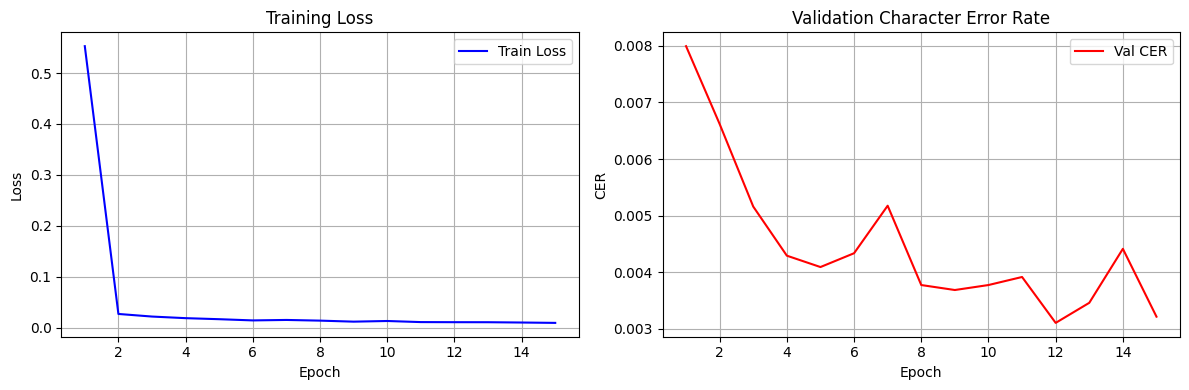


📊 TRAINING SUMMARY
Total training time: 121.3 minutes
Best validation CER: 0.0031
Best validation accuracy: 99.69%
Final training loss: 0.0095
Final validation CER: 0.0032

📁 Saved model files:
   - best_model.pth
   - training_history.json
   - model_info.json
   - model_config.json
   - training_curves.png
   - idx_to_char.json
   - char_to_idx.json

📦 PREPARING MODEL FOR UPLOAD TO PUBLIC SHARED DRIVE
✅ Created zip file: /content/geez_crnn_model.zip
   Size: 1536.14 MB

📤 UPLOAD TO PUBLIC SHARED DRIVE

Since this is a public shared Drive (not your own),
please manually upload the model to the shared folder.

Follow these steps:
1. Click the download button below to download the model zip file
2. Open the shared Drive link:
   https://drive.google.com/drive/folders/1Bn-cg_t4YR-HbOduP0_y_xBV-aEQ93K_
3. Navigate to the 'geez_crnn_model' folder
4. Upload the downloaded zip file
5. Extract the zip file in the Drive folder

📥 Downloading model zip file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Model ready for manual upload to public shared Drive!
   Local model path: /content/geez_crnn_model
   Zip file: /content/geez_crnn_model.zip


In [13]:
# @title 11. Train the Model (COMPLETE) + Save Checkpoints + Upload to Public Shared Drive
from datetime import datetime
from tqdm import tqdm
import shutil
from torch.utils.data import DataLoader, Dataset
import torch.nn.utils.rnn as rnn_utils

# Define collate function FIRST (before it's used)
def collate_fn(batch):
    """Collate function for variable length sequences"""
    images = []
    labels = []
    label_lengths = []
    texts = []

    for img, label, length, text in batch:
        images.append(img)
        labels.append(label)
        label_lengths.append(length)
        texts.append(text)

    images = torch.stack(images, 0)

    # Pad labels
    labels_padded = rnn_utils.pad_sequence(labels, batch_first=True, padding_value=0)

    return images, labels_padded, torch.tensor(label_lengths), texts

# Check if we should train (respect FORCE_TRAINING if defined)
should_train = not USE_EXISTING_MODEL
if 'FORCE_TRAINING' in dir() and FORCE_TRAINING:
    should_train = True
    print("⚠️ FORCE_TRAINING is enabled - training even if model exists")

# Only train if we should
if should_train:

    # Create DataLoaders if they don't exist
    if 'train_loader' not in dir() or len(train_loader) == 0:
        print("Creating DataLoaders...")

        # Define the Dataset class
        class GeezDataset(Dataset):
            def __init__(self, pairs, char_to_idx, transform=None):
                self.pairs = pairs
                self.char_to_idx = char_to_idx
                self.transform = transform

            def __len__(self):
                return len(self.pairs)

            def __getitem__(self, idx):
                image, text = self.pairs[idx]

                if isinstance(image, Image.Image):
                    image = np.array(image)

                if self.transform:
                    transformed = self.transform(image=image)
                    image = transformed['image']

                # Convert text to indices
                label = [self.char_to_idx[char] for char in text]

                return image, torch.tensor(label, dtype=torch.long), len(label), text

        # Define transforms
        train_transform = A.Compose([
            A.Resize(height=64, width=256),
            A.Normalize(mean=[0.5], std=[0.5]),
            ToTensorV2()
        ])

        val_transform = A.Compose([
            A.Resize(height=64, width=256),
            A.Normalize(mean=[0.5], std=[0.5]),
            ToTensorV2()
        ])

        # Create datasets
        train_dataset = GeezDataset(train_pairs, char_to_idx, train_transform)
        val_dataset = GeezDataset(val_pairs, char_to_idx, val_transform)
        test_dataset = GeezDataset(test_pairs, char_to_idx, val_transform)

        # Create data loaders (use the collate_fn defined above)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, collate_fn=collate_fn)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=collate_fn)
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=collate_fn)

        print(f"✅ DataLoaders created:")
        print(f"   Training batches: {len(train_loader)}")
        print(f"   Validation batches: {len(val_loader)}")
        print(f"   Test batches: {len(test_loader)}")

    # Check if training functions exist (from Cell 10)
    if 'train_epoch' not in dir():
        print("❌ train_epoch function not defined. Please run Cell 10 first.")
        train_epoch = None
        evaluate = None

    if len(train_loader) > 0 and model is not None and train_epoch is not None:
        # Training parameters
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        num_epochs = 15

        print("=" * 60)
        print(f"🚀 TRAINING STARTED")
        print(f"   Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Device: {device}")
        print(f"   Training samples: {len(train_pairs)}")
        print(f"   Validation samples: {len(val_pairs)}")
        print(f"   Test samples: {len(test_pairs)}")
        print(f"   Number of classes: {num_classes}")
        print(f"   Model parameters: {sum(p.numel() for p in model.parameters()):,}")
        print("=" * 60)

        best_cer = float('inf')
        training_history = []

        # Create checkpoint directory
        checkpoint_dir = f"{OUTPUT_PATH}/checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)

        for epoch in range(num_epochs):
            epoch_start = datetime.now()

            # Train
            train_loss = train_epoch(model, train_loader, optimizer, device)

            # Validate
            val_cer, predictions, ground_truths = evaluate(model, val_loader, device, idx_to_char)

            # Update learning rate
            old_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_cer)
            current_lr = optimizer.param_groups[0]['lr']

            epoch_time = (datetime.now() - epoch_start).total_seconds()

            # Print learning rate change
            if current_lr != old_lr:
                print(f"  📉 Learning rate reduced from {old_lr:.6f} to {current_lr:.6f}")

            # Save checkpoint every epoch
            epoch_checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_cer': val_cer,
                'train_loss': train_loss,
                'char_to_idx': char_to_idx,
                'idx_to_char': idx_to_char
            }
            torch.save(epoch_checkpoint, f"{checkpoint_dir}/checkpoint_epoch_{epoch+1}.pth")

            # Save best model
            if val_cer < best_cer:
                best_cer = val_cer
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_cer': val_cer,
                    'char_to_idx': char_to_idx,
                    'idx_to_char': idx_to_char
                }, f"{OUTPUT_PATH}/best_model.pth")
                print(f"  ✅ New best model! CER: {best_cer:.4f}")

            # Record history
            training_history.append({
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'val_cer': val_cer,
                'lr': current_lr,
                'time': epoch_time
            })

            print(f"Epoch {epoch+1}/{num_epochs}: Loss={train_loss:.4f}, Val CER={val_cer:.4f}, LR={current_lr:.6f}, Time={epoch_time:.1f}s")

        print("=" * 60)
        print(f"✅ TRAINING COMPLETED: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"🎯 Best CER: {best_cer:.4f}")
        print(f"🎯 Best Accuracy: {(1 - best_cer) * 100:.2f}%")
        print("=" * 60)

        # Save training history
        with open(f"{OUTPUT_PATH}/training_history.json", 'w') as f:
            json.dump(training_history, f, indent=2)

        # Save character mappings (multiple formats for compatibility)
        mappings = {
            'char_to_idx': char_to_idx,
            'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
            'num_classes': num_classes,
            'best_cer': best_cer,
            'training_completed': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        with open(f"{checkpoint_dir}/char_mappings.json", 'w', encoding='utf-8') as f:
            json.dump(mappings, f, ensure_ascii=False, indent=2)

        # Also save separate mapping files for Cell 1 compatibility
        with open(f"{OUTPUT_PATH}/char_to_idx.json", 'w', encoding='utf-8') as f:
            json.dump(char_to_idx, f, ensure_ascii=False, indent=2)

        with open(f"{OUTPUT_PATH}/idx_to_char.json", 'w', encoding='utf-8') as f:
            json.dump({str(k): v for k, v in idx_to_char.items()}, f, ensure_ascii=False, indent=2)

        # Save model config
        model_config = {
            'num_classes': num_classes,
            'hidden_size': 256,
            'input_height': 64,
            'input_width': 256
        }
        with open(f"{OUTPUT_PATH}/model_config.json", 'w', encoding='utf-8') as f:
            json.dump(model_config, f, indent=2)

        # Create model info file
        model_info = {
            'model_name': "Ge'ez Script Recognition CRNN Model",
            'architecture': 'CRNN with CNN + BiLSTM',
            'input_size': '64x256 grayscale',
            'num_classes': num_classes,
            'best_cer': best_cer,
            'best_accuracy': (1 - best_cer) * 100,
            'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'training_samples': len(train_pairs),
            'validation_samples': len(val_pairs),
            'test_samples': len(test_pairs),
            'shared_folder_id': SHARED_FOLDER_ID,
            'shared_folder_url': f"https://drive.google.com/drive/folders/{SHARED_FOLDER_ID}"
        }
        with open(f"{OUTPUT_PATH}/model_info.json", 'w', encoding='utf-8') as f:
            json.dump(model_info, f, indent=2, ensure_ascii=False)

        # Plot training history
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot([h['epoch'] for h in training_history], [h['train_loss'] for h in training_history], 'b-', label='Train Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot([h['epoch'] for h in training_history], [h['val_cer'] for h in training_history], 'r-', label='Val CER')
        plt.xlabel('Epoch')
        plt.ylabel('CER')
        plt.title('Validation Character Error Rate')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig(f"{OUTPUT_PATH}/training_curves.png")
        plt.show()

        # Print final summary
        print("\n" + "=" * 60)
        print("📊 TRAINING SUMMARY")
        print("=" * 60)
        print(f"Total training time: {sum([h['time'] for h in training_history])/60:.1f} minutes")
        print(f"Best validation CER: {best_cer:.4f}")
        print(f"Best validation accuracy: {(1 - best_cer) * 100:.2f}%")
        print(f"Final training loss: {training_history[-1]['train_loss']:.4f}")
        print(f"Final validation CER: {training_history[-1]['val_cer']:.4f}")

        # List saved files
        print("\n📁 Saved model files:")
        for f in os.listdir(OUTPUT_PATH):
            if f.endswith('.pth') or f.endswith('.json') or f.endswith('.png'):
                print(f"   - {f}")

        # ============================================================
        # CREATE ZIP FILE FOR UPLOAD TO PUBLIC SHARED DRIVE
        # ============================================================
        print("\n" + "=" * 60)
        print("📦 PREPARING MODEL FOR UPLOAD TO PUBLIC SHARED DRIVE")
        print("=" * 60)

        # Create a zip file of the entire model
        zip_path = f"{OUTPUT_PATH}.zip"
        shutil.make_archive(OUTPUT_PATH, 'zip', OUTPUT_PATH)
        print(f"✅ Created zip file: {zip_path}")
        print(f"   Size: {os.path.getsize(zip_path) / 1024 / 1024:.2f} MB")

        # Provide download link for the user to manually upload
        from google.colab import files

        print("\n" + "=" * 60)
        print("📤 UPLOAD TO PUBLIC SHARED DRIVE")
        print("=" * 60)
        print("\nSince this is a public shared Drive (not your own),")
        print("please manually upload the model to the shared folder.")
        print("\nFollow these steps:")
        print(f"1. Click the download button below to download the model zip file")
        print("2. Open the shared Drive link:")
        print(f"   https://drive.google.com/drive/folders/{SHARED_FOLDER_ID}")
        print("3. Navigate to the 'geez_crnn_model' folder")
        print("4. Upload the downloaded zip file")
        print("5. Extract the zip file in the Drive folder")

        # Download the zip file locally
        print("\n📥 Downloading model zip file...")
        files.download(zip_path)

        print("\n✅ Model ready for manual upload to public shared Drive!")
        print(f"   Local model path: {OUTPUT_PATH}")
        print(f"   Zip file: {zip_path}")

    else:
        print("❌ Cannot train: No data loaders or model available")
        if len(train_loader) == 0:
            print("   - train_loader is empty")
        if model is None:
            print("   - model is None")
        if train_epoch is None:
            print("   - train_epoch function not defined")

else:
    print("=" * 60)
    print("✅ USING EXISTING MODEL - Skipping training")
    print("=" * 60)
    print(f"Model already exists at: {OUTPUT_PATH}")
    print("No training needed. The model is ready for inference!")

    # Display model info if available
    info_file = f"{OUTPUT_PATH}/model_info.json"
    if os.path.exists(info_file):
        with open(info_file, 'r', encoding='utf-8') as f:
            info = json.load(f)
        print(f"\n📊 Existing Model Info:")
        print(f"   Training date: {info.get('training_date', 'Unknown')}")
        print(f"   Best CER: {info.get('best_cer', 'N/A')}")
        print(f"   Best accuracy: {info.get('best_accuracy', 'N/A')}%")

🔍 TESTING MODEL ON SAMPLE IMAGE
✅ Dataset found at: /content/combined/combined

✅ Using dataset path: /content/combined/combined
✅ Found image: /content/combined/combined/tig_000001.png

📖 GROUND TRUTH: ምቑራፅን ዝተቆረፀ ምትካእን ሓደ
📏 Ground truth length: 20 characters

🔧 APPLYING PREPROCESSING PIPELINE
📸 Original image size: (598, 93)

Preprocessing steps applied:
  1. Remove borders
  2. Deskew (skew correction)
  3. Remove noise (bilateral filter)
  4. Enhance contrast (CLAHE)
  5. Adaptive thresholding
  6. Resize to height 64 (maintaining aspect ratio)
  7. Pad to width 256
📸 Processed image size: (64, 256)

🤖 MODEL INFERENCE
📊 Input tensor shape: torch.Size([1, 1, 64, 256])

🎯 PREDICTION: ምቑራፅን ዝተቆረፀ ምትካእን ሓደ
📏 Prediction length: 20 characters

📊 COMPARISON RESULT

✅ EXACT MATCH! 🎉
The model correctly recognized the entire text!

🖼️ VISUALIZATION


/tmp/ipykernel_1056/4194673880.py:254: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:254: UserWarning: Glyph 4637 (\N{ETHIOPIC SYLLABLE ME}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:254: UserWarning: Glyph 4689 (\N{ETHIOPIC SYLLABLE QHU}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:254: UserWarning: Glyph 4651 (\N{ETHIOPIC SYLLABLE RAA}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:254: UserWarning: Glyph 4933 (\N{ETHIOPIC SYLLABLE TZE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:254: UserWarning: Glyph 4757 (\N{ETHIOPIC SYLLABLE NE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:254: UserWarning: Glyph 4829 (\N{ETHIOPIC SYLLABLE ZE}) missing from fo

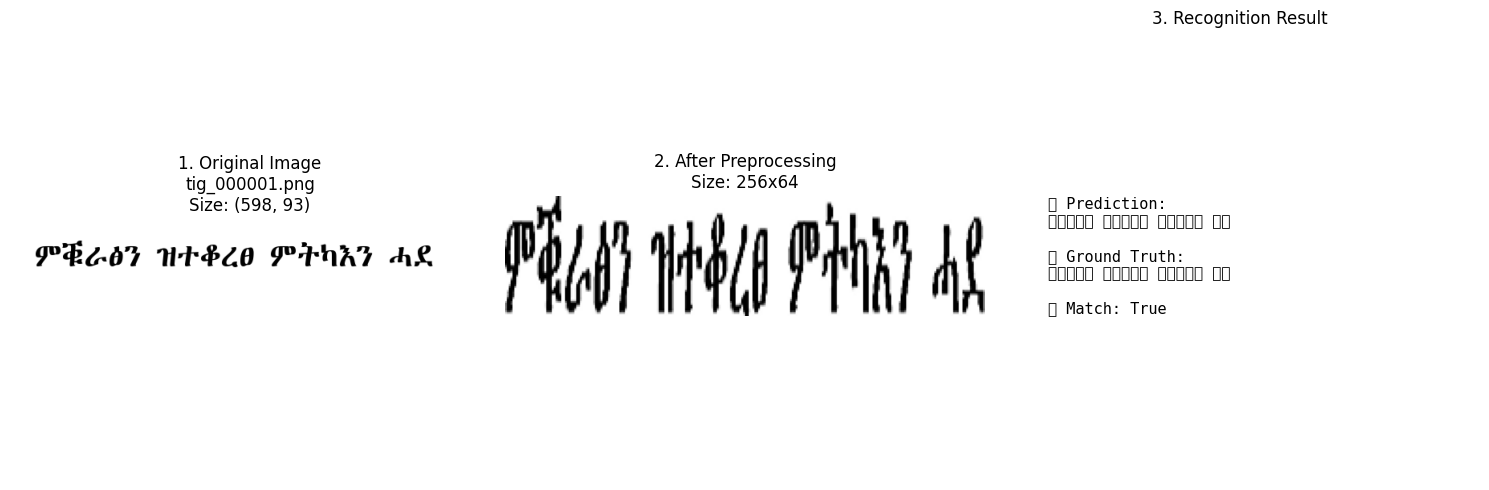

/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4637 (\N{ETHIOPIC SYLLABLE ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4689 (\N{ETHIOPIC SYLLABLE QHU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4651 (\N{ETHIOPIC SYLLABLE RAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4933 (\N{ETHIOPIC SYLLABLE TZE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4757 (\N{ETHIOPIC SYLLABLE NE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4829 (\N{ETHIOPIC SYLLABLE ZE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4720 (\N{ETHIOPIC SYLLABLE TA}) missing from font(s) DejaVu Sans.
  p


📋 FINAL SUMMARY
Image: tig_000001.png
Ground Truth: ምቑራፅን ዝተቆረፀ ምትካእን ሓደ
Prediction:   ምቑራፅን ዝተቆረፀ ምትካእን ሓደ
Match Status: ✅ CORRECT

🔍 ADDITIONAL TESTING OPTION
To test on more images, run the following code:


/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4627 (\N{ETHIOPIC SYLLABLE HHAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4848 (\N{ETHIOPIC SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4637 (\N{ETHIOPIC SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4689 (\N{ETHIOPIC SYLLABLE QHU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4651 (\N{ETHIOPIC SYLLABLE RAA}) missing from font(s) DejaVu Sans.
  fi

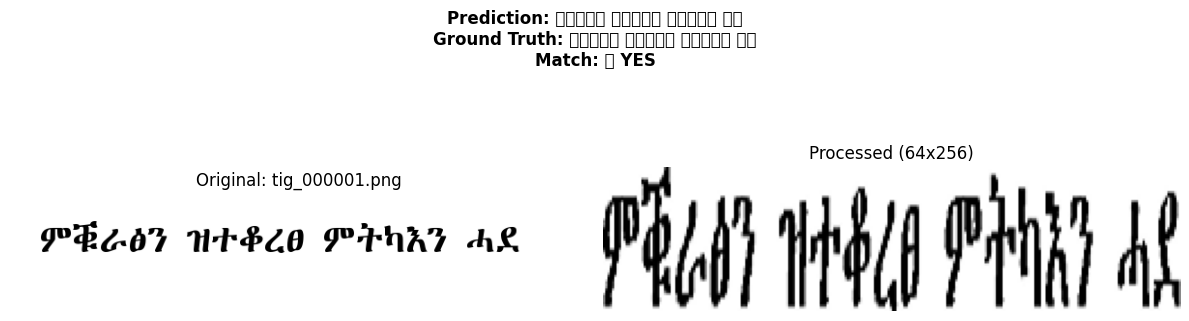

Image: tig_000001.png
Ground Truth: ምቑራፅን ዝተቆረፀ ምትካእን ሓደ
Prediction:   ምቑራፅን ዝተቆረፀ ምትካእን ሓደ
Match: ✅ YES



/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4771 (\N{ETHIOPIC SYLLABLE GLOTTAL AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4709 (\N{ETHIOPIC SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4752 (\N{ETHIOPIC SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4821 (\N{ETHIOPIC SYLLABLE PHARYNGEAL E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4672 (\N{ETHIOPIC SYLLABLE QA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4707 (\N{ETHIOPIC SYLLABLE BAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4849 (\N{ETHIOPIC SYLLABLE DU}) missing from font(s) 

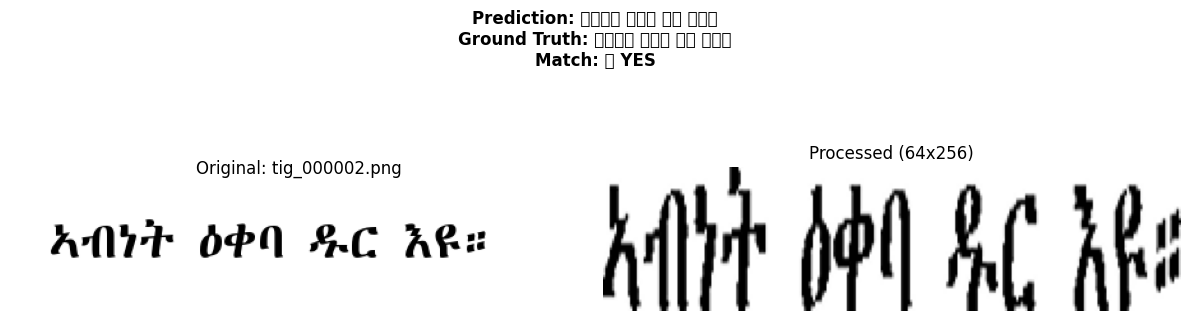

Image: tig_000002.png
Ground Truth: ኣብነት ዕቀባ ዱር እዩ።
Prediction:   ኣብነት ዕቀባ ዱር እዩ።
Match: ✅ YES



/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4931 (\N{ETHIOPIC SYLLABLE TZAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4629 (\N{ETHIOPIC SYLLABLE HHE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4843 (\N{ETHIOPIC SYLLABLE YAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4845 (\N{ETHIOPIC SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4797 (\N{ETHIOPIC SYLLABLE KXE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4621 (\N{ETHIOPIC SYLLABLE LE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4723 (\N{ETHIOPIC SYLLABLE TAA}) missing from font(s) DejaVu Sans.


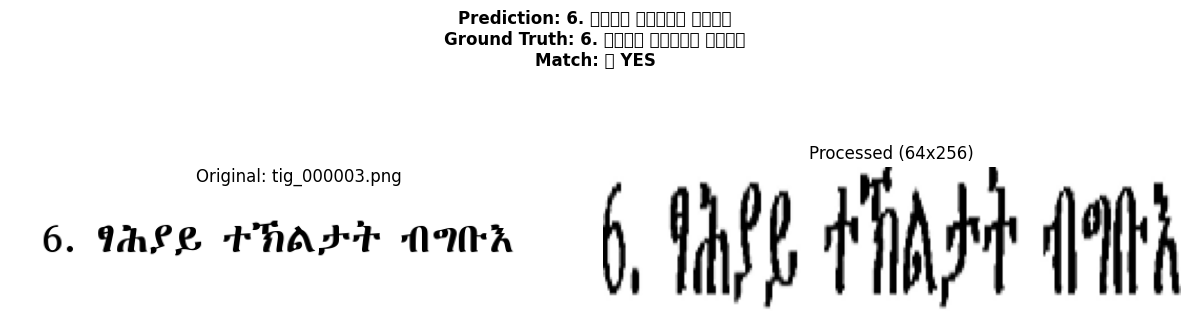

Image: tig_000003.png
Ground Truth: 6. ፃሕያይ ተኽልታት ብግቡእ
Prediction:   6. ፃሕያይ ተኽልታት ብግቡእ
Match: ✅ YES



/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4792 (\N{ETHIOPIC SYLLABLE KXA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4819 (\N{ETHIOPIC SYLLABLE PHARYNGEAL AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4824 (\N{ETHIOPIC SYLLABLE ZA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4616 (\N{ETHIOPIC SYLLABLE LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4840 (\N{ETHIOPIC SYLLABLE YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4618 (\N{ETHIOPIC SYLLABLE LI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4792 (\N{ETHIOPIC SYLLABLE 

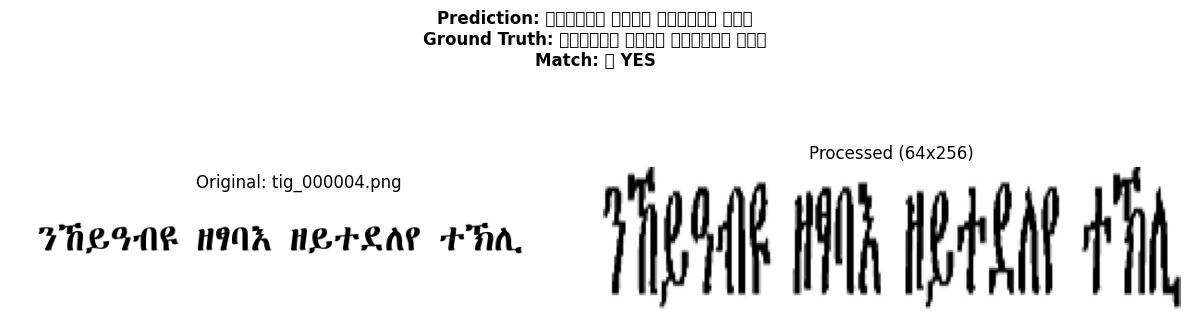

Image: tig_000004.png
Ground Truth: ንኸይዓብዩ ዘፃባእ ዘይተደለየ ተኽሊ
Prediction:   ንኸይዓብዩ ዘፃባእ ዘይተደለየ ተኽሊ
Match: ✅ YES



/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4781 (\N{ETHIOPIC SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1056/4194673880.py:340: UserWarning: Glyph 4798 (\N{ETHIOPIC SYLLABLE KXO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4781 (\N{ETHIOPIC SYLLABLE KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4798 (\N{ETHIOPIC SYLLABLE KXO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


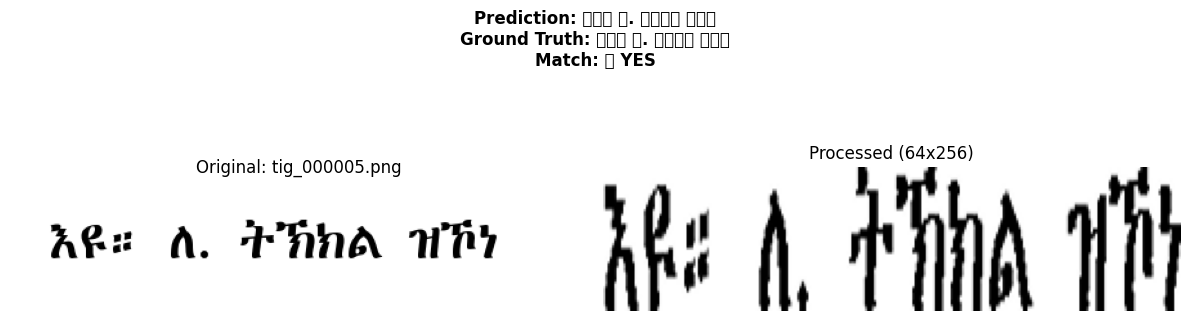

Image: tig_000005.png
Ground Truth: እዩ። ለ. ትኽክል ዝኾነ
Prediction:   እዩ። ለ. ትኽክል ዝኾነ
Match: ✅ YES



In [14]:
# @title 12. Test Model on Sample Image (ALWAYS runs - for verification)
print("=" * 60)
print("🔍 TESTING MODEL ON SAMPLE IMAGE")
print("=" * 60)

# CORRECT DATASET PATH from your notebook (matches Cell 1 extraction)
DATASET_PATH = "/content/combined/combined"

# Verify dataset exists with better handling
dataset_found = False
actual_path = None

# Check main path
if os.path.exists(DATASET_PATH):
    dataset_found = True
    actual_path = DATASET_PATH
    print(f"✅ Dataset found at: {DATASET_PATH}")
else:
    print(f"⚠️ Dataset not found at: {DATASET_PATH}")

    # Try alternative paths
    alt_paths = [
        "/content/combined",
        "/content/dataset10/dataset10",
        "/content/data",
        "/content/dataset"
    ]

    for alt_path in alt_paths:
        if os.path.exists(alt_path):
            # Check if it contains images
            test_files = glob.glob(f"{alt_path}/*.png")
            if test_files:
                dataset_found = True
                actual_path = alt_path
                print(f"✅ Using alternative path: {actual_path} (found {len(test_files)} images)")
                break

    if not dataset_found:
        print("❌ Dataset not found in any expected location.")
        print("\n📂 Contents of /content:")
        !ls -la /content/
        print("\n⚠️ Cannot run test - no dataset available")
        # Don't exit, just skip gracefully
        ground_truth = ""
        prediction = ""
        original_img = None
        processed_np = None
        skip_test = True

if 'skip_test' not in dir():
    skip_test = False

if not skip_test and dataset_found:
    DATASET_PATH = actual_path
    print(f"\n✅ Using dataset path: {DATASET_PATH}")

    # Test image (using the same sample from your notebook)
    image_file = "tig_000001.png"
    image_path = os.path.join(DATASET_PATH, image_file)
    gt_path = os.path.join(DATASET_PATH, image_file.replace('.png', '.gt.txt'))

    # If that specific image doesn't exist, find any image
    if not os.path.exists(image_path):
        print(f"⚠️ {image_file} not found, looking for any test image...")
        png_files = glob.glob(f"{DATASET_PATH}/*.png")
        if png_files:
            image_path = png_files[0]
            gt_path = image_path.replace('.png', '.gt.txt')
            print(f"✅ Using alternative image: {os.path.basename(image_path)}")
        else:
            print("❌ No images found in dataset")
            print("⚠️ Skipping test - no images available")
            skip_test = True

if not skip_test and dataset_found:
    # Check if files exist
    if os.path.exists(image_path):
        print(f"✅ Found image: {image_path}")
    else:
        print(f"❌ Image not found: {image_path}")
        skip_test = True

if not skip_test and dataset_found:
    # Read ground truth
    if os.path.exists(gt_path):
        with open(gt_path, 'r', encoding='utf-8') as f:
            ground_truth = f.read().strip()
        print(f"\n📖 GROUND TRUTH: {ground_truth}")
        print(f"📏 Ground truth length: {len(ground_truth)} characters")
    else:
        print(f"⚠️ Ground truth file not found: {gt_path}")
        ground_truth = ""

    # ============================================================
    # APPLY PREPROCESSING PIPELINE
    # ============================================================

    print("\n" + "=" * 60)
    print("🔧 APPLYING PREPROCESSING PIPELINE")
    print("=" * 60)

    # Load image as grayscale
    original_img = Image.open(image_path).convert('L')
    print(f"📸 Original image size: {original_img.size}")

    print("\nPreprocessing steps applied:")
    print("  1. Remove borders")
    print("  2. Deskew (skew correction)")
    print("  3. Remove noise (bilateral filter)")
    print("  4. Enhance contrast (CLAHE)")
    print("  5. Adaptive thresholding")
    print("  6. Resize to height 64 (maintaining aspect ratio)")
    print("  7. Pad to width 256")

    # Apply full preprocessing
    processed_img = EnhancedImagePreprocessor.full_preprocessing(original_img)

    # Convert to numpy for display
    if isinstance(processed_img, Image.Image):
        processed_np = np.array(processed_img)
    else:
        processed_np = processed_img

    print(f"📸 Processed image size: {processed_np.shape}")

    # ============================================================
    # MODEL INFERENCE
    # ============================================================

    print("\n" + "=" * 60)
    print("🤖 MODEL INFERENCE")
    print("=" * 60)

    # Check if model is loaded
    if model is None:
        print("❌ Model not loaded! Please check the model loading cell.")
        print("⚠️ Skipping inference - no model available")
        skip_test = True

if not skip_test and dataset_found and model is not None:
    # Prepare for model
    if isinstance(processed_img, Image.Image):
        img_np = np.array(processed_img)
    else:
        img_np = processed_img

    # Ensure grayscale and correct dimensions
    if len(img_np.shape) == 2:
        img_np = np.expand_dims(img_np, axis=-1)

    # Apply transforms (same as training)
    transform = A.Compose([
        A.Resize(height=64, width=256),
        A.Normalize(mean=[0.5], std=[0.5]),
        ToTensorV2()
    ])

    transformed = transform(image=img_np)
    img_tensor = transformed['image'].unsqueeze(0).to(device)

    print(f"📊 Input tensor shape: {img_tensor.shape}")

    # Run inference
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prediction = ctc_decode(output.cpu(), idx_to_char)[0]

    print(f"\n🎯 PREDICTION: {prediction}")
    print(f"📏 Prediction length: {len(prediction)} characters")

    # ============================================================
    # COMPARE RESULTS
    # ============================================================

    if ground_truth:
        print("\n" + "=" * 60)
        print("📊 COMPARISON RESULT")
        print("=" * 60)

        if prediction == ground_truth:
            print("\n✅ EXACT MATCH! 🎉")
            print("The model correctly recognized the entire text!")
        else:
            print("\n❌ MISMATCH DETECTED")
            print("\n🔍 Character-by-character comparison:")
            print("-" * 60)

            max_len = max(len(prediction), len(ground_truth))
            print(f"{'Pos':<5} {'Prediction':<15} {'Ground Truth':<15} {'Match':<10}")
            print("-" * 60)

            for i in range(max_len):
                pred_char = prediction[i] if i < len(prediction) else '∅'
                gt_char = ground_truth[i] if i < len(ground_truth) else '∅'
                match = "✓" if pred_char == gt_char else "✗"
                pred_display = f"'{pred_char}'"
                gt_display = f"'{gt_char}'"
                print(f"{i+1:<5} {pred_display:<15} {gt_display:<15} {match}")

            print("-" * 60)

            # Calculate accuracy
            matches = sum(1 for i in range(min(len(prediction), len(ground_truth)))
                          if i < len(prediction) and i < len(ground_truth) and prediction[i] == ground_truth[i])
            total_chars = max(len(prediction), len(ground_truth))
            char_accuracy = matches / total_chars * 100 if total_chars > 0 else 0

            print(f"\n📈 Character Accuracy: {char_accuracy:.1f}% ({matches}/{total_chars} chars)")

            if len(prediction) != len(ground_truth):
                print(f"📏 Length difference: Prediction({len(prediction)}) vs Ground Truth({len(ground_truth)})")

    # ============================================================
    # VISUALIZATION
    # ============================================================

    print("\n" + "=" * 60)
    print("🖼️ VISUALIZATION")
    print("=" * 60)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(np.array(original_img), cmap='gray')
    axes[0].set_title(f'1. Original Image\n{os.path.basename(image_path)}\nSize: {original_img.size}')
    axes[0].axis('off')

    # After preprocessing
    axes[1].imshow(processed_np, cmap='gray')
    axes[1].set_title(f'2. After Preprocessing\nSize: {processed_np.shape[1]}x{processed_np.shape[0]}')
    axes[1].axis('off')

    # Prediction result
    result_text = f'🎯 Prediction:\n{prediction}\n'
    if ground_truth:
        result_text += f'\n📖 Ground Truth:\n{ground_truth}\n\n✅ Match: {prediction == ground_truth}'
    else:
        result_text += f'\n⚠️ No ground truth available'

    axes[2].text(0.1, 0.5, result_text, fontsize=11, verticalalignment='center', family='monospace')
    axes[2].set_title('3. Recognition Result')
    axes[2].axis('off')

    # Add color coding
    if ground_truth and prediction == ground_truth:
        axes[2].set_facecolor('#90EE90')  # Light green
    elif ground_truth:
        axes[2].set_facecolor('#FFB6C1')  # Light pink
    else:
        axes[2].set_facecolor('#FFFACD')  # Light yellow

    plt.tight_layout()
    plt.show()

    # ============================================================
    # SUMMARY
    # ============================================================

    print("\n" + "=" * 60)
    print("📋 FINAL SUMMARY")
    print("=" * 60)
    print(f"Image: {os.path.basename(image_path)}")
    if ground_truth:
        print(f"Ground Truth: {ground_truth[:100]}{'...' if len(ground_truth) > 100 else ''}")
    print(f"Prediction:   {prediction[:100]}{'...' if len(prediction) > 100 else ''}")
    if ground_truth:
        print(f"Match Status: {'✅ CORRECT' if prediction == ground_truth else '❌ INCORRECT'}")
    print("=" * 60)

else:
    print("\n" + "=" * 60)
    print("⚠️ TEST SKIPPED")
    print("=" * 60)
    print("Unable to run test due to missing dataset or model.")
    print("Please ensure:")
    print("1. Dataset is extracted correctly")
    print("2. Model is loaded successfully")

print("\n" + "=" * 60)
print("🔍 ADDITIONAL TESTING OPTION")
print("=" * 60)
print("To test on more images, run the following code:")
for i in range(1, 6):
    test_file = f"tig_{i:06d}.png"
    test_path = os.path.join(DATASET_PATH, test_file)
    if os.path.exists(test_path):
        gt_path = test_path.replace('.png', '.gt.txt')

        # Load and preprocess image
        original_img = Image.open(test_path).convert('L')
        processed_img = EnhancedImagePreprocessor.full_preprocessing(original_img)

        # Prepare for model
        if isinstance(processed_img, Image.Image):
            img_np = np.array(processed_img)
        else:
            img_np = processed_img

        if len(img_np.shape) == 2:
            img_np = np.expand_dims(img_np, axis=-1)

        transform = A.Compose([
            A.Resize(height=64, width=256),
            A.Normalize(mean=[0.5], std=[0.5]),
            ToTensorV2()
        ])

        transformed = transform(image=img_np)
        img_tensor = transformed['image'].unsqueeze(0).to(device)

        # Run inference
        model.eval()
        with torch.no_grad():
            output = model(img_tensor)
            prediction = ctc_decode(output.cpu(), idx_to_char)[0]

        # Read ground truth
        ground_truth = ""
        if os.path.exists(gt_path):
            with open(gt_path, 'r', encoding='utf-8') as f:
                ground_truth = f.read().strip()

        # Display image and results
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Original image
        axes[0].imshow(np.array(original_img), cmap='gray')
        axes[0].set_title(f'Original: {test_file}')
        axes[0].axis('off')

        # Processed image
        axes[1].imshow(img_np.squeeze(), cmap='gray')
        axes[1].set_title(f'Processed (64x256)')
        axes[1].axis('off')

        plt.suptitle(f'Prediction: {prediction}\nGround Truth: {ground_truth}\nMatch: {"✅ YES" if prediction == ground_truth else "❌ NO"}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Print results
        print(f"{'='*50}")
        print(f"Image: {test_file}")
        print(f"Ground Truth: {ground_truth}")
        print(f"Prediction:   {prediction}")
        print(f"Match: {'✅ YES' if prediction == ground_truth else '❌ NO'}")
        print(f"{'='*50}\n")

🔍 VERIFYING MODEL STATUS
✅ Model is LOADED in memory from previous cell
   Device: cuda

✅ Model verification passed! Ready to extract.

🚀 STARTING PAGE TEXT EXTRACTION
📄 PROCESSING FULL PAGE IMAGE
Image: /content/page_0005.png
📸 Original image size: (3301, 2550)

🔧 Preprocessing full page...
   After preprocessing: (2651, 1969)

🔍 Detecting text regions...
   Found 940 text regions

📏 Grouping into text lines...
   Identified 31 text lines

✂️ Extracting line images...
   Extracted 31 line images

🤖 Running inference on each line...
   Line   1: ውፀኢት ስራሕ ሃኛ፣ ካልኣይ ጉጅሰ ወፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ
   Line   2: ውፅኢት ስራሕ ሰራሒ ሸኸላ ወዘተ ከዘዚርዝሩ ምግባር፡ ብምቕጸል ወፅኢት
   Line   3: 
   Line   4: ስራሕ እዞም ሰሐ ጣ ካብ ምንታይ ካብ ምንታይ ከምዝተሰርሑን ገዝዕብዎ
   Line   5: ሞቕምን ክዝልፁ ምጥዛባር፡ ሓበሪታ ንመምህር፦ ፍልጠትን ከእለትን ውልቀ
   Line   6: ተፈጥሮ ብምጥቃም ዝተፈላለዩ ወጋፅታት ኣቀሑ ዝ ፣ ዓብባታት ከም ኩታን
   Line   7: ጋጊን፣ መንድቕ ገጥ፣ ማሕረሻ? ስራሕቲ ኸኽላ ንኣብነት ከም ዕትሮ፣ ኻት
   Line   8: ቑ
   Line   9: ሞጎ፣ ፃሕሊ፣ ወዘተ 4 3ይ ኬፍሲ ኤስቴቲኒክስን ጥንካረ ኣካልን ዝበስርኡ
   Line  10: ከብሙያ ይባየሃሉ

/tmp/ipykernel_1056/3091513966.py:351: UserWarning: Glyph 4813 (\N{ETHIOPIC SYLLABLE WE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3091513966.py:351: UserWarning: Glyph 4928 (\N{ETHIOPIC SYLLABLE TZA}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3091513966.py:351: UserWarning: Glyph 4770 (\N{ETHIOPIC SYLLABLE GLOTTAL I}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3091513966.py:351: UserWarning: Glyph 4725 (\N{ETHIOPIC SYLLABLE TE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3091513966.py:351: UserWarning: Glyph 4661 (\N{ETHIOPIC SYLLABLE SE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3091513966.py:351: UserWarning: Glyph 4651 (\N{ETHIOPIC SYLLABLE RAA}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3091513966.py:351: UserWarning: Glyph 4629 (\N{ETHIOPIC SYLLABLE HHE}) 

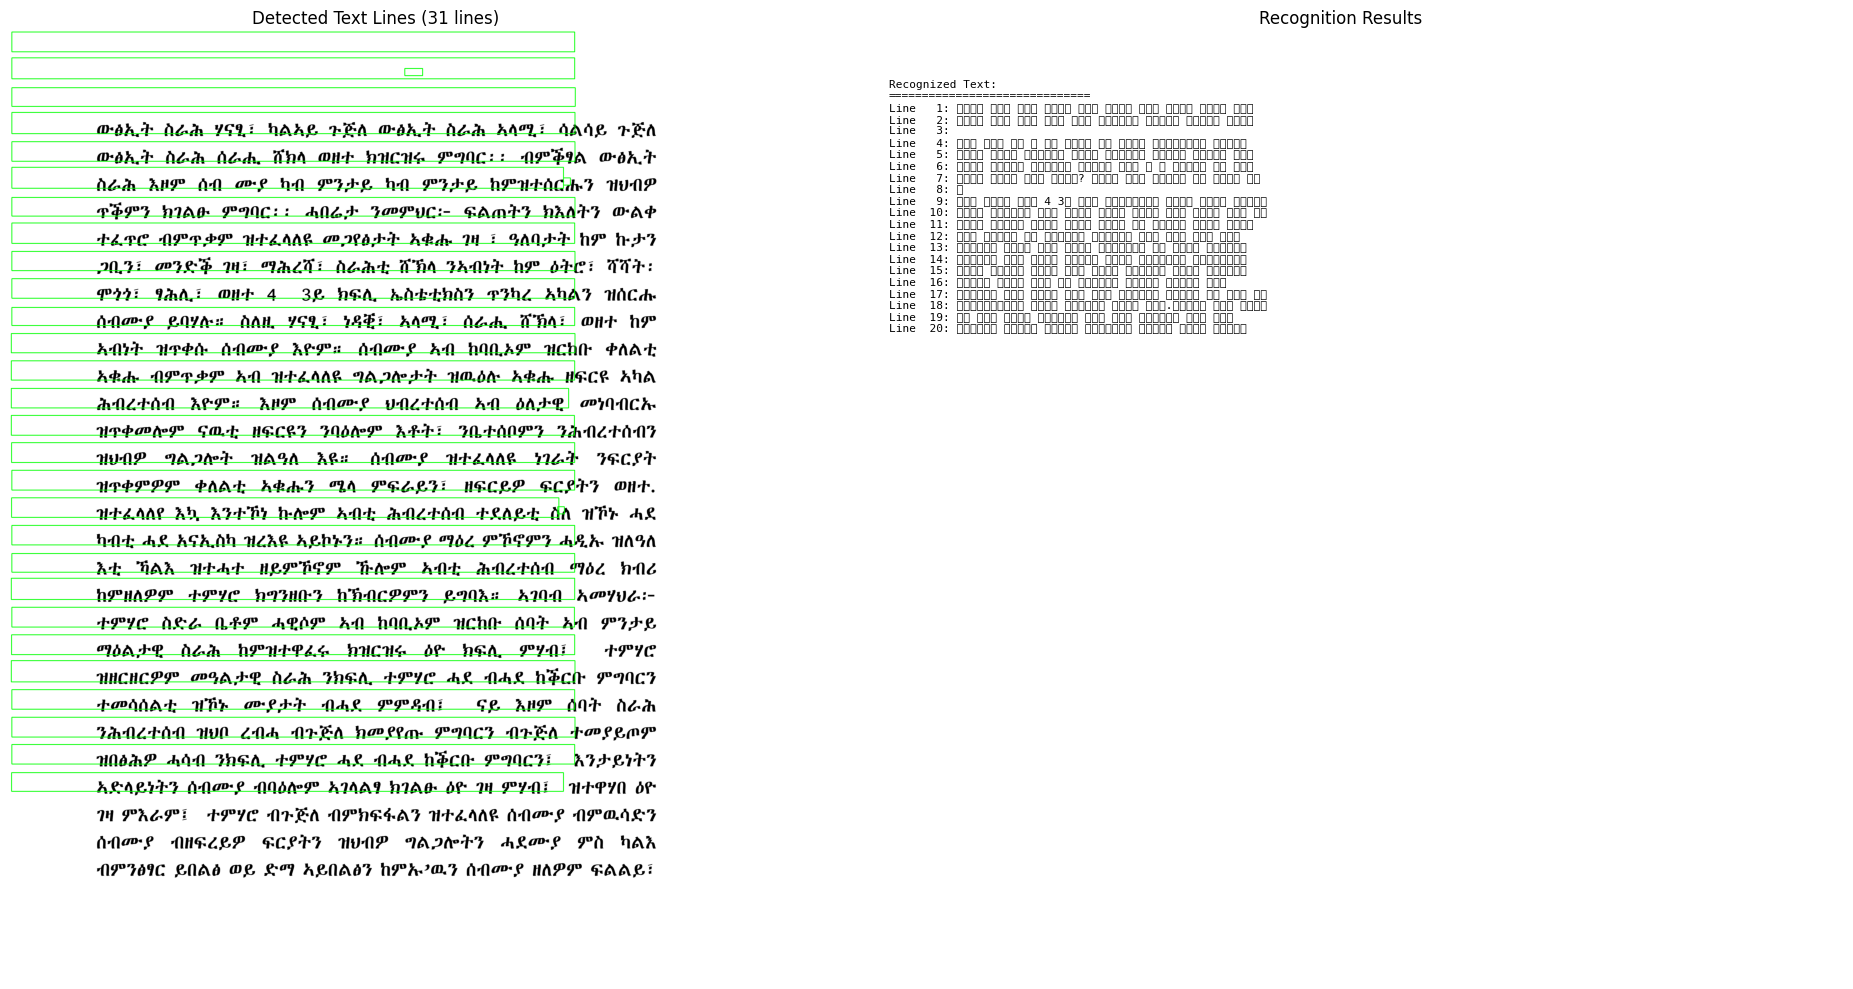


📝 FULL PAGE RECOGNIZED TEXT
ውፀኢት ስራሕ ሃኛ፣ ካልኣይ ጉጅሰ ወፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ
ውፅኢት ስራሕ ሰራሒ ሸኸላ ወዘተ ከዘዚርዝሩ ምግባር፡ ብምቕጸል ወፅኢት

ስራሕ እዞም ሰሐ ጣ ካብ ምንታይ ካብ ምንታይ ከምዝተሰርሑን ገዝዕብዎ
ሞቕምን ክዝልፁ ምጥዛባር፡ ሓበሪታ ንመምህር፦ ፍልጠትን ከእለትን ውልቀ
ተፈጥሮ ብምጥቃም ዝተፈላለዩ ወጋፅታት ኣቀሑ ዝ ፣ ዓብባታት ከም ኩታን
ጋጊን፣ መንድቕ ገጥ፣ ማሕረሻ? ስራሕቲ ኸኽላ ንኣብነት ከም ዕትሮ፣ ኻት
ቑ
ሞጎ፣ ፃሕሊ፣ ወዘተ 4 3ይ ኬፍሲ ኤስቴቲኒክስን ጥንካረ ኣካልን ዝበስርኡ
ከብሙያ ይባየሃሉ። ስለሊ የናፂ፣ ነይቒ፣ ኣላሚ፣ ሰራሒ ሸኸላ፣ ወዘተ ከም
ኣብክት ዝጥቀሱ። ስብመያ እዮዎ። ከብሙያ ኣብ ከባቢኦም ዝርከቡ ቀለልቲ
ኣቁሑ ብምጥቃም ኣብ ዝተፈላለዩ ግልገቀታት ዝወሉ ኣቁቱ ፍርዒ ኣካል
ሕብረተስብ እዮም። እዎም ክብሙያ ዘቀብረተስብ ኣብ ዕሲታዊ መነባብርኡ
ዝጥቀመሎም ናዉቲ ፍርዩን ንባዕሎም እቶት፣ ንርተሰቦምን ንሕብረተሰብን
ዝህብፆ ግልጋዮት ዝልናሰ እዩ። ስብሙያ ዝተፈላለዩ ነገራት ንፍርያምት
ዝቀምዎም ቀለልቲ ኣሑን ሜስ ምጉፍራይ፣ ዝፍርይዎ ፍርያትን ወዘተ
ዝተፈላለየ እኻእ እንተኻ አሎም ኣብቲ ሕብረተከብ ተደለይቲ ስለ ዝኾኑ ሓደ
ካብቲሓደአናኛኢስ ዝረእዩ ኣይኮኑን። ሰብሙያ ማለረ.ምኾኖምን ሓዲኡ ዝለዓለ
እቲ ኻልእ ዝተሓተ ዘይምኾየም ኹሎም ኣብቲ ሕብረተስብ ማስረ ክብሪ
ከምዘለዎም ተምሃዚሮ ክንዝቡን ከኸብርዎምን ይግባእ። ኣገባብ ኣመሃህራ
ኡ
ተዎሃሮ ስድራ ቤቶም ሓዊስም ኣብ ከባቢኦም ዝር1ኩ ስባት ኣብ ምንታይ
ማዕልታዊ ስራሕ ከምዝተዋፈሩ ክዝርዘሩ ዕዮ ክፍሊ ምማብ፤ ጎምየሮ
ዝዘዚርዘርዎም መዓልቃዊ ስራሕ ንክፍሊ ተምሃዚሮ ሓደ ብሓደ ከቕርቡ ምግባርን
ተመሰልቲ ዝኾኑ ሙያታት ብሓደ ምምዳብ፤ ናይ 

In [33]:
# @title Full Page Image to Text Line Extraction and Recognition (FINAL - Works with trained model)
"""
This section extracts text lines from a full page image in reading order,
applies the SAME preprocessing as your training pipeline,
and recognizes each line using your ALREADY TRAINED CRNN model.

IMPORTANT: Run Cell 1 and Cell 9 FIRST to load the model into memory!
"""

import cv2
import numpy as np
from PIL import Image
import os
import torch
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import json

# ============================================================
# VERIFY MODEL IS LOADED (Run Cell 1 and Cell 9 first!)
# ============================================================
print("=" * 60)
print("🔍 VERIFYING MODEL STATUS")
print("=" * 60)

model_loaded = False

# Check if model is already loaded from previous cells
if 'model' in dir() and model is not None:
    model_loaded = True
    print("✅ Model is LOADED in memory from previous cell")
    print(f"   Device: {device if 'device' in dir() else 'cuda'}")

if 'idx_to_char' not in dir() or idx_to_char is None:
    print("⚠️ Character mappings not in memory, attempting to load...")
    OUTPUT_PATH = "/content/geez_crnn_model"
    mappings_path = f"{OUTPUT_PATH}/char_mappings.json"

    if os.path.exists(mappings_path):
        with open(mappings_path, 'r', encoding='utf-8') as f:
            mappings = json.load(f)
            idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
        print(f"✅ Loaded character mappings: {len(idx_to_char)} characters")

if not model_loaded:
    print("\n❌ Model NOT loaded!")
    print("=" * 60)
    print("Please run these cells FIRST in order:")
    print("   Cell 1 (Setup - downloads model if needed)")
    print("   Cell 9 (Loads the model into memory)")
    print("\nThen run this cell again.")
    print("=" * 60)
else:
    print("\n✅ Model verification passed! Ready to extract.")
    print("=" * 60)

# ============================================================
# PAGE LAYOUT ANALYSIS AND LINE EXTRACTION
# ============================================================

if model_loaded:

    class FullPageTextExtractor:
        """Extract text lines from a full page image in reading order."""

        def __init__(self, model, idx_to_char, device, preprocessor,
                     min_line_height=15, max_line_height=100,
                     vertical_gap_threshold=15):
            self.model = model
            self.idx_to_char = idx_to_char
            self.device = device
            self.preprocessor = preprocessor
            self.min_line_height = min_line_height
            self.max_line_height = max_line_height
            self.vertical_gap_threshold = vertical_gap_threshold

        def load_image(self, image_path):
            """Load image as grayscale numpy array."""
            img = Image.open(image_path).convert('L')
            return np.array(img)

        def apply_preprocessing_to_numpy(self, img_np):
            """Apply the same preprocessing pipeline to numpy array."""
            img_pil = Image.fromarray(img_np)
            processed = self.preprocessor.full_preprocessing(img_pil)
            if isinstance(processed, Image.Image):
                processed = np.array(processed)
            return processed

        def deskew_image(self, image):
            """Deskew the entire page image."""
            coords = np.column_stack(np.where(image < 250))
            if len(coords) > 0:
                angle = cv2.minAreaRect(coords)[-1]
                if angle < -45:
                    angle = -(90 + angle)
                else:
                    angle = -angle
                if abs(angle) > 0.5:
                    (h, w) = image.shape[:2]
                    center = (w // 2, h // 2)
                    M = cv2.getRotationMatrix2D(center, angle, 1.0)
                    image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC,
                                          borderMode=cv2.BORDER_REPLICATE)
            return image

        def remove_borders(self, image):
            """Remove white borders from image."""
            _, thresh = cv2.threshold(image, 250, 255, cv2.THRESH_BINARY_INV)
            coords = cv2.findNonZero(thresh)
            if coords is not None:
                x, y, w, h = cv2.boundingRect(coords)
                padding = 10
                x = max(0, x - padding)
                y = max(0, y - padding)
                w = min(image.shape[1] - x, w + 2 * padding)
                h = min(image.shape[0] - y, h + 2 * padding)
                return image[y:y+h, x:x+w]
            return image

        def detect_text_regions(self, image):
            """Detect text regions using morphological operations."""
            inverted = cv2.bitwise_not(image)
            _, binary = cv2.threshold(inverted, 127, 255, cv2.THRESH_BINARY)
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
            dilated = cv2.dilate(binary, kernel, iterations=2)
            contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            text_regions = []
            for contour in contours:
                x, y, w, h = cv2.boundingRect(contour)
                if h >= self.min_line_height and h <= self.max_line_height and w > h * 0.5:
                    text_regions.append((x, y, w, h))

            text_regions.sort(key=lambda r: (r[1], r[0]))
            return text_regions

        def group_into_lines(self, text_regions):
            """Group regions into lines based on vertical proximity."""
            if not text_regions:
                return []

            lines = []
            current_line = [text_regions[0]]

            for region in text_regions[1:]:
                prev_region = current_line[-1]
                vertical_gap = abs(region[1] - prev_region[1])

                if vertical_gap < self.vertical_gap_threshold:
                    current_line.append(region)
                else:
                    lines.append(current_line)
                    current_line = [region]

            lines.append(current_line)

            for line in lines:
                line.sort(key=lambda r: r[0])

            return lines

        def extract_line_images(self, image, lines):
            """Extract individual line images from the page."""
            line_images = []

            for line_idx, line_regions in enumerate(lines):
                if not line_regions:
                    continue

                min_x = min(r[0] for r in line_regions)
                max_x = max(r[0] + r[2] for r in line_regions)
                min_y = min(r[1] for r in line_regions)
                max_y = max(r[1] + r[3] for r in line_regions)

                padding = 5
                min_x = max(0, min_x - padding)
                max_x = min(image.shape[1], max_x + padding)
                min_y = max(0, min_y - padding)
                max_y = min(image.shape[0], max_y + padding)

                line_img = image[min_y:max_y, min_x:max_x]

                line_images.append({
                    'image': line_img,
                    'position': (min_y, min_x),
                    'line_idx': line_idx,
                    'bbox': (min_x, min_y, max_x, max_y)
                })

            return line_images

        def preprocess_for_model(self, line_img):
            """Preprocess a line image for model input."""
            if len(line_img.shape) == 3:
                line_img = cv2.cvtColor(line_img, cv2.COLOR_BGR2GRAY)

            processed = self.apply_preprocessing_to_numpy(line_img)

            if len(processed.shape) == 2:
                processed = np.expand_dims(processed, axis=-1)

            transform = A.Compose([
                A.Resize(height=64, width=256),
                A.Normalize(mean=[0.5], std=[0.5]),
                ToTensorV2()
            ])

            transformed = transform(image=processed)
            img_tensor = transformed['image'].unsqueeze(0).to(self.device)

            return img_tensor

        def predict_line(self, line_img):
            """Run prediction on a single line image."""
            img_tensor = self.preprocess_for_model(line_img)

            self.model.eval()
            with torch.no_grad():
                output = self.model(img_tensor)
                prediction = self.decode_output(output.cpu())[0]

            return prediction

        def decode_output(self, output):
            """Decode CTC output to text."""
            output = output.argmax(2)
            texts = []
            for seq in output:
                text = []
                prev = -1
                for idx in seq:
                    idx = idx.item()
                    if idx != prev and idx != 0:
                        text.append(self.idx_to_char.get(idx, '?'))
                    prev = idx
                texts.append(''.join(text))
            return texts

        def process_page(self, image_path, output_dir=None, visualize=True):
            """Process a full page image and extract all text lines in order."""
            print("=" * 60)
            print("📄 PROCESSING FULL PAGE IMAGE")
            print("=" * 60)
            print(f"Image: {image_path}")

            if not os.path.exists(image_path):
                print(f"❌ Image not found: {image_path}")
                return None

            original_img = self.load_image(image_path)
            print(f"📸 Original image size: {original_img.shape}")

            print("\n🔧 Preprocessing full page...")
            img = self.remove_borders(original_img)
            img = self.deskew_image(img)
            print(f"   After preprocessing: {img.shape}")

            print("\n🔍 Detecting text regions...")
            text_regions = self.detect_text_regions(img)
            print(f"   Found {len(text_regions)} text regions")

            print("\n📏 Grouping into text lines...")
            lines = self.group_into_lines(text_regions)
            print(f"   Identified {len(lines)} text lines")

            print("\n✂️ Extracting line images...")
            line_items = self.extract_line_images(img, lines)
            print(f"   Extracted {len(line_items)} line images")

            print("\n🤖 Running inference on each line...")
            predictions = []

            for i, item in enumerate(line_items):
                line_img = item['image']
                prediction = self.predict_line(line_img)
                predictions.append(prediction)
                print(f"   Line {i+1:3d}: {prediction[:50]}{'...' if len(prediction) > 50 else ''}")

            full_text = '\n'.join(predictions)

            print("\n" + "=" * 60)
            print("✅ PAGE PROCESSING COMPLETE")
            print("=" * 60)
            print(f"Total lines extracted: {len(predictions)}")
            print(f"Total characters recognized: {sum(len(p) for p in predictions)}")

            if output_dir:
                self.save_line_images(line_items, predictions, output_dir)

            if visualize:
                self.visualize_results(original_img, line_items, predictions)

            return {
                'predictions': predictions,
                'line_images': line_items,
                'full_text': full_text,
                'num_lines': len(predictions),
                'image_shape': original_img.shape
            }

        def save_line_images(self, line_items, predictions, output_dir, base_name="line"):
            """Save extracted line images to a folder."""
            os.makedirs(output_dir, exist_ok=True)

            for i, item in enumerate(line_items):
                line_img = item['image']
                prediction = predictions[i] if i < len(predictions) else ""

                img_path = os.path.join(output_dir, f"{base_name}_{i+1:04d}.png")
                Image.fromarray(line_img).save(img_path)

                gt_path = os.path.join(output_dir, f"{base_name}_{i+1:04d}.gt.txt")
                with open(gt_path, 'w', encoding='utf-8') as f:
                    f.write(prediction)

            full_text_path = os.path.join(output_dir, "full_text.txt")
            with open(full_text_path, 'w', encoding='utf-8') as f:
                f.write('\n'.join(predictions))

            print(f"\n📁 Saved {len(line_items)} line images to: {output_dir}")
            print(f"📄 Full text saved to: {full_text_path}")

        def visualize_results(self, original_img, line_items, predictions):
            """Visualize the original image with detected line bounding boxes."""
            fig, axes = plt.subplots(1, 2, figsize=(20, 10))

            img_with_boxes = cv2.cvtColor(original_img.copy(), cv2.COLOR_GRAY2RGB)

            for item in line_items:
                x1, y1, x2, y2 = item['bbox']
                cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)

            axes[0].imshow(img_with_boxes)
            axes[0].set_title(f'Detected Text Lines ({len(line_items)} lines)', fontsize=12)
            axes[0].axis('off')

            text_display = ""
            for i, pred in enumerate(predictions[:20]):
                text_display += f"Line {i+1:3d}: {pred[:70]}\n"
                if len(pred) > 70:
                    text_display += f"{' '*8}{pred[70:]}\n"

            axes[1].text(0.05, 0.95, "Recognized Text:\n" + "="*30 + "\n" + text_display,
                        transform=axes[1].transAxes, fontsize=8,
                        verticalalignment='top', fontfamily='monospace')
            axes[1].set_title('Recognition Results', fontsize=12)
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()


    # ============================================================
    # MAIN EXECUTION - Process your page image
    # ============================================================

    # Set your image path (change this to your actual image)
    image_path = "/content/page_0005.png"

    # Set output directory
    output_dir = "/content/extracted_page_lines"

    print("\n" + "=" * 60)
    print("🚀 STARTING PAGE TEXT EXTRACTION")
    print("=" * 60)

    # Run the extraction
    if os.path.exists(image_path):
        extractor = FullPageTextExtractor(
            model=model,
            idx_to_char=idx_to_char,
            device=device if 'device' in dir() else torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
            preprocessor=EnhancedImagePreprocessor,
            min_line_height=15,
            max_line_height=100,
            vertical_gap_threshold=15
        )

        result = extractor.process_page(
            image_path=image_path,
            output_dir=output_dir,
            visualize=True
        )

        if result:
            print("\n" + "=" * 60)
            print("📝 FULL PAGE RECOGNIZED TEXT")
            print("=" * 60)
            print(result['full_text'])
            print("=" * 60)
            print(f"\n📊 SUMMARY:")
            print(f"   Lines detected: {result['num_lines']}")
            print(f"   Total characters: {sum(len(p) for p in result['predictions'])}")
    else:
        print(f"\n❌ Image not found: {image_path}")
        print("Please upload your page image to /content/ or change the path.")

    print("\n" + "=" * 60)
    print("✅ Page extraction complete!")
    print("=" * 60)

else:
    print("\n⚠️ Cannot run extraction - model not loaded.")
    print("Please run Cell 1 and Cell 9 first, then run this cell again.")

In [34]:
# @title Calculate CER and Accuracy - Compare with Ground Truth
"""
This cell calculates Character Error Rate (CER) and Accuracy
by comparing recognized text with ground truth.
"""

import os

# ============================================================
# PATHS
# ============================================================

# Path to your recognized full text (from extraction)
recognized_text_path = "/content/extracted_page_lines/full_text.txt"

# Path to your ground truth text file
ground_truth_path = "/content/page_0005.txt"

# ============================================================
# FUNCTIONS
# ============================================================

def calculate_cer(predicted, ground_truth):
    """
    Calculate Character Error Rate (CER)
    CER = (Insertions + Deletions + Substitutions) / Length of Ground Truth
    Lower is better (0 = perfect)
    """
    if len(ground_truth) == 0:
        return 0 if len(predicted) == 0 else 1.0

    pred_list = list(predicted)
    gt_list = list(ground_truth)

    n, m = len(pred_list), len(gt_list)

    # Dynamic programming for Levenshtein distance
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if pred_list[i-1] == gt_list[j-1]:
                cost = 0
            else:
                cost = 1
            dp[i][j] = min(
                dp[i-1][j] + 1,      # deletion
                dp[i][j-1] + 1,      # insertion
                dp[i-1][j-1] + cost  # substitution
            )

    cer = dp[n][m] / m
    return cer


def calculate_accuracy(predicted, ground_truth):
    """Calculate character-level accuracy percentage."""
    if len(ground_truth) == 0:
        return 0

    matches = 0
    min_len = min(len(predicted), len(ground_truth))
    for i in range(min_len):
        if predicted[i] == ground_truth[i]:
            matches += 1

    accuracy = (matches / max(len(predicted), len(ground_truth))) * 100
    return accuracy


def load_text_file(file_path):
    """Load text from file."""
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read().strip()
    else:
        print(f"❌ File not found: {file_path}")
        return None


# ============================================================
# CALCULATE AND DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("📊 CER AND ACCURACY CALCULATION")
print("=" * 60)

# Load texts
recognized_text = load_text_file(recognized_text_path)
ground_truth_text = load_text_file(ground_truth_path)

if recognized_text and ground_truth_text:

    print(f"\n📄 Recognized text length: {len(recognized_text)} characters")
    print(f"📖 Ground truth length: {len(ground_truth_text)} characters")

    # Calculate CER
    cer = calculate_cer(recognized_text, ground_truth_text)

    # Calculate Accuracy
    accuracy = calculate_accuracy(recognized_text, ground_truth_text)

    # Calculate Word Error Rate (WER) - optional
    recognized_words = recognized_text.split()
    ground_truth_words = ground_truth_text.split()

    # Simple word accuracy
    word_matches = 0
    for i in range(min(len(recognized_words), len(ground_truth_words))):
        if recognized_words[i] == ground_truth_words[i]:
            word_matches += 1

    word_accuracy = (word_matches / max(len(recognized_words), len(ground_truth_words))) * 100

    print("\n" + "=" * 60)
    print("📊 RESULTS")
    print("=" * 60)
    print(f"🎯 Character Error Rate (CER): {cer:.4f} ({cer*100:.2f}%)")
    print(f"✅ Character Accuracy: {accuracy:.2f}%")
    print(f"📝 Word Accuracy: {word_accuracy:.2f}%")
    print("=" * 60)

    # Interpretation
    print("\n📈 INTERPRETATION:")
    if cer < 0.05:
        print("   ✅ Excellent! Very low error rate.")
    elif cer < 0.10:
        print("   👍 Good! Acceptable error rate.")
    elif cer < 0.20:
        print("   ⚠️ Moderate error rate. May need improvement.")
    else:
        print("   ❌ High error rate. Model may need more training.")

    # Show sample comparison
    print("\n🔍 SAMPLE COMPARISON (First 200 chars):")
    print("-" * 60)
    print(f"Recognized:  {recognized_text[:200]}...")
    print(f"Ground Truth: {ground_truth_text[:200]}...")
    print("-" * 60)

    # Calculate editing distance details
    pred_list = list(recognized_text)
    gt_list = list(ground_truth_text)
    n, m = len(pred_list), len(gt_list)

    # Levenshtein matrix for detailed stats
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if pred_list[i-1] == gt_list[j-1]:
                cost = 0
            else:
                cost = 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)

    # Backtrack to count operations (approximate)
    i, j = n, m
    deletions = insertions = substitutions = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and pred_list[i-1] == gt_list[j-1]:
            i -= 1
            j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            substitutions += 1
            i -= 1
            j -= 1
        elif i > 0 and dp[i][j] == dp[i-1][j] + 1:
            deletions += 1
            i -= 1
        else:
            insertions += 1
            j -= 1

    print(f"\n📊 ERROR BREAKDOWN:")
    print(f"   Insertions: {insertions} (added characters)")
    print(f"   Deletions: {deletions} (missing characters)")
    print(f"   Substitutions: {substitutions} (wrong characters)")
    print(f"   Total errors: {insertions + deletions + substitutions}")
    print(f"   Ground truth length: {m}")

else:
    if not recognized_text:
        print(f"❌ Could not load recognized text from: {recognized_text_path}")
    if not ground_truth_text:
        print(f"❌ Could not load ground truth from: {ground_truth_path}")

    print("\n💡 TIP: Make sure:")
    print("   1. The extraction cell ran successfully")
    print("   2. The ground truth file exists at /content/page_0005.txt")

print("\n" + "=" * 60)
print("✅ Evaluation complete!")
print("=" * 60)

📊 CER AND ACCURACY CALCULATION

📄 Recognized text length: 1255 characters
📖 Ground truth length: 1297 characters

📊 RESULTS
🎯 Character Error Rate (CER): 0.1542 (15.42%)
✅ Character Accuracy: 4.32%
📝 Word Accuracy: 12.40%

📈 INTERPRETATION:
   ⚠️ Moderate error rate. May need improvement.

🔍 SAMPLE COMPARISON (First 200 chars):
------------------------------------------------------------
Recognized:  ውፀኢት ስራሕ ሃኛ፣ ካልኣይ ጉጅሰ ወፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ
ውፅኢት ስራሕ ሰራሒ ሸኸላ ወዘተ ከዘዚርዝሩ ምግባር፡ ብምቕጸል ወፅኢት

ስራሕ እዞም ሰሐ ጣ ካብ ምንታይ ካብ ምንታይ ከምዝተሰርሑን ገዝዕብዎ
ሞቕምን ክዝልፁ ምጥዛባር፡ ሓበሪታ ንመምህር፦ ፍልጠትን ከእለትን ውልቀ
ተፈጥሮ ብምጥቃም ዝተፈላለዩ ወጋ...
Ground Truth: ውፅኢት ስራሕ ሃናፂ፣ ካልኣይ ጉጅለ ውፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ 
ውፅኢት ስራሕ ሰራሒ ሸክላ ወዘተ ክዝርዝሩ ምግባር፡፡ ብምቕፃል ውፅኢት 
ስራሕ እዞም ሰብ ሙያ ካብ ምንታይ ካብ ምንታይ ከምዝተሰርሑን ዝህብዎ 
ጥቕምን ክገልፁ ምግባር፡፡ ሓበሬታ ንመምህር፦ ፍልጠትን ክእለትን ውልቀ 
ተፈጥሮ ብምጥቃም ዝተፈላለ...
------------------------------------------------------------

📊 ERROR BREAKDOWN:
   Insertions: 59 (added characters)
   Deletions: 17 (missing characters)
   Substitutions: 

🔍 VERIFYING MODEL STATUS
✅ Model is LOADED
✅ Ready!
📄 PROCESSING FULL PAGE IMAGE (Optimized)
Image: /content/page_0005.png
📸 Original: (3301, 2550)

🔧 Optimized preprocessing...
   After preprocessing: (2707, 2025)

🔍 Detecting text lines...
   Found 28 lines

🤖 Recognizing lines...
   Line   1: ወፅኢት ስራሕ ማኛፂ፣ ካልኣይ ጉጅለ ወፅኢት ስራሕ ኣላሚ፣ ስልሳይ ጉዃለ
   Line   2: ፀህኢት ስራሕ ሰራሒ ሽኸላ ወዘተ ዝዚርዝሩ ምግባር፡ ብምቕል ውኢት
   Line   3: ስራሕ እዮም ሰብ ውያ ካብ ምንታይ ካብ ምንታይ ከምዝተስርሑን ገዝበብዎ
   Line   4: ጥቅምን ከገልፁ ምግባር።፡ ሓበሬታ ንመምነበር፦ ፍልትን ከእለትን ውልቀ
   Line   5: ተፈጥሮ ብምጥቃም ዝተፈላለዩ ወጋዝሽታት ኣቁሑ ዝጣ ፣ ዓለባታት ከም ኩታን
   Line   6: ጋቢን፣ መንድቕ ገዛገ፣ ማሕረሻ፣ ስራሕቲ ሸኸላ ንኣብነት ከም ዕትር፣ ሻት
   Line   7: ሞጎ፣ ፃሕሊ፣ ወዘሃጎ -4 3ይ ከፍሊ ኤስቴቲክስን ጥንካረ ኣካል? ዝስርኡ
   Line   8: ከብሙያ ይየሃሉ። ስለዚ ዓናፂ፣ ከዳቒ፣ ኣዳሚ፣ ስራሒ ሸኽሳ፣ ወዘተ ከም
   Line   9: ኣብት ዝጥቀሱ ስብመያ እዮም። ስብሙያ ኣብ ከባቢኦዎ ዝርከቡ ቀለልቲ
   Line  10: ኣቁሑ ብምጥቃም ኣብ ዝተፈላለዩ ግልገቀታት ዝወሉ ኣቁቱ ፍርኑ ሓካል
   Line  11: ሕብረተከክብ እዮም። እሞም ሰብሙያ ህተብረተከብ ኣብ ዕሲታዊ መከባብርኡ
   Line  12: ዝጥቀመሎም ናዉቲ ፍርን ንባዕሎም እቶት፣ ንጌተሰቦምን ንሕብረተከብን
   Line  13: ዘህብዎ ግልጋ

/tmp/ipykernel_1056/3054072455.py:364: UserWarning: Glyph 4808 (\N{ETHIOPIC SYLLABLE WA}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3054072455.py:364: UserWarning: Glyph 4933 (\N{ETHIOPIC SYLLABLE TZE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3054072455.py:364: UserWarning: Glyph 4770 (\N{ETHIOPIC SYLLABLE GLOTTAL I}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3054072455.py:364: UserWarning: Glyph 4725 (\N{ETHIOPIC SYLLABLE TE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3054072455.py:364: UserWarning: Glyph 4661 (\N{ETHIOPIC SYLLABLE SE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3054072455.py:364: UserWarning: Glyph 4651 (\N{ETHIOPIC SYLLABLE RAA}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1056/3054072455.py:364: UserWarning: Glyph 4629 (\N{ETHIOPIC SYLLABLE HHE}) 

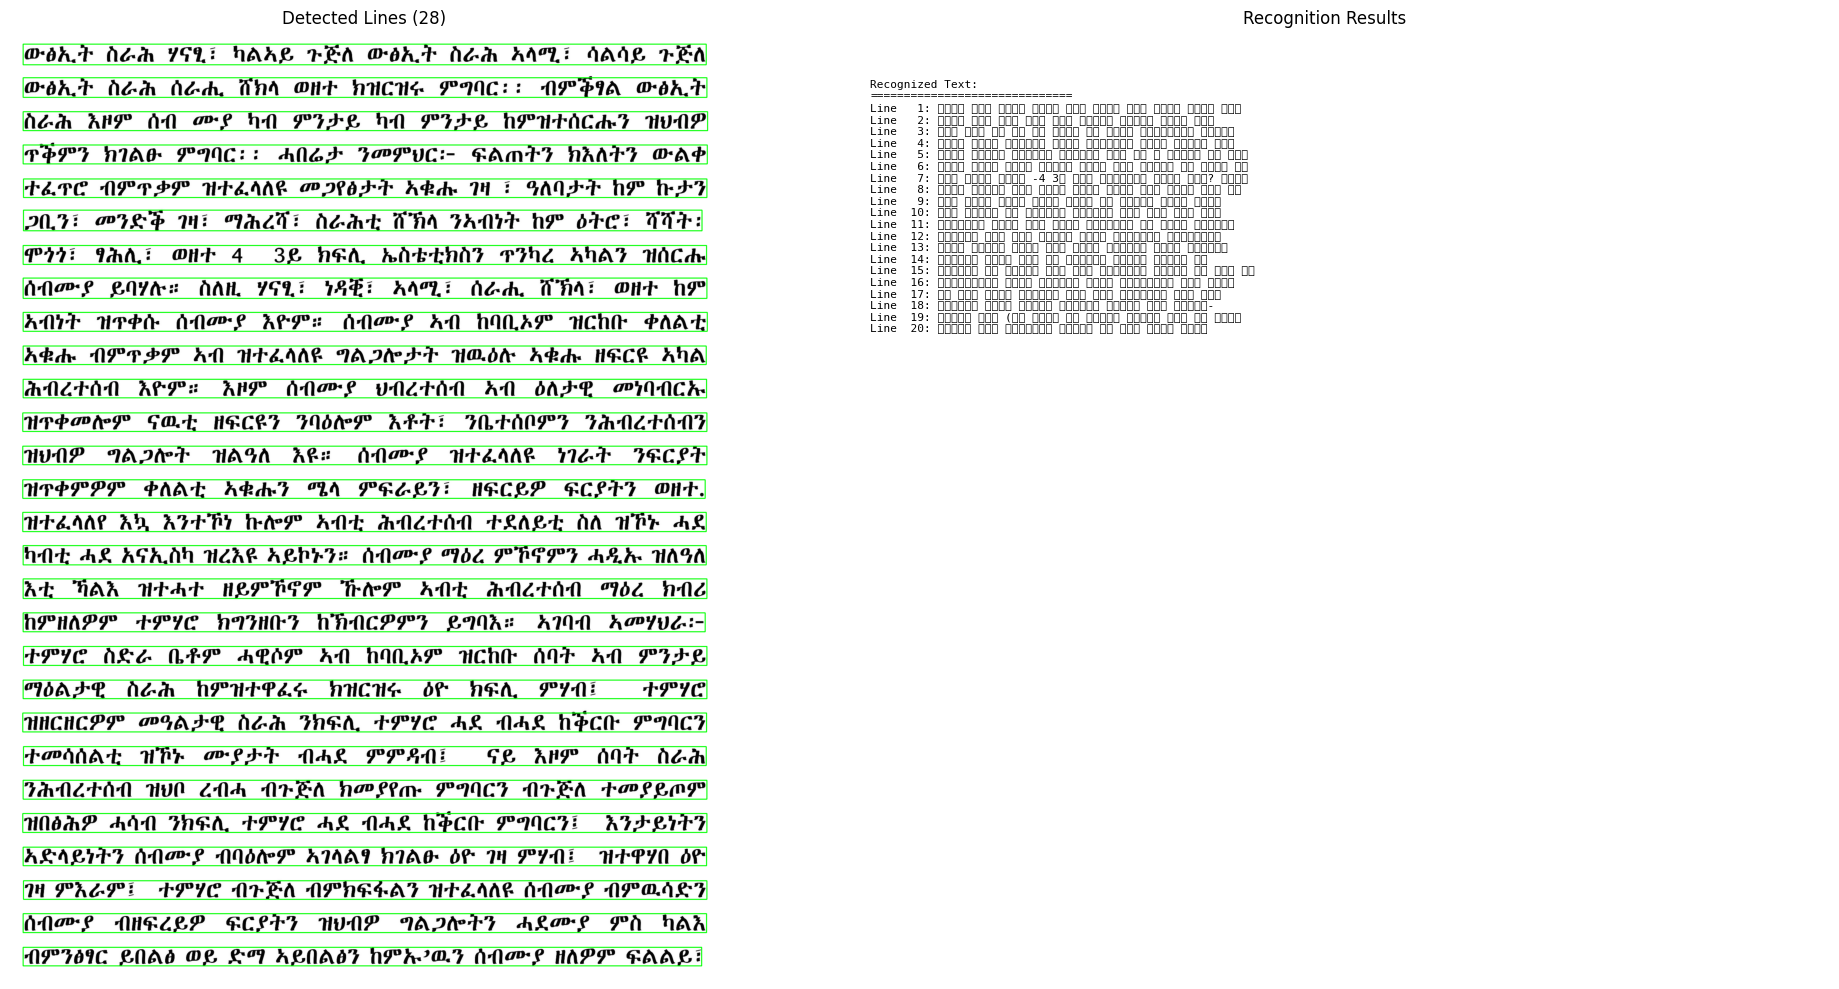


🎯 RESULTS vs GROUND TRUTH
✅ Character Accuracy: 82.96%
❌ Character Error Rate: 0.1704 (17.04%)
📖 Ground truth length: 1297
📄 Recognized length: 1245

🔍 First line comparison:
   Predicted: ወፅኢት ስራሕ ማኛፂ፣ ካልኣይ ጉጅለ ወፅኢት ስራሕ ኣላሚ፣ ስልሳይ ጉዃለ
   Ground truth: ውፅኢት ስራሕ ሃናፂ፣ ካልኣይ ጉጅለ ውፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ 

📝 FULL PAGE TEXT
ወፅኢት ስራሕ ማኛፂ፣ ካልኣይ ጉጅለ ወፅኢት ስራሕ ኣላሚ፣ ስልሳይ ጉዃለ
ፀህኢት ስራሕ ሰራሒ ሽኸላ ወዘተ ዝዚርዝሩ ምግባር፡ ብምቕል ውኢት
ስራሕ እዮም ሰብ ውያ ካብ ምንታይ ካብ ምንታይ ከምዝተስርሑን ገዝበብዎ
ጥቅምን ከገልፁ ምግባር።፡ ሓበሬታ ንመምነበር፦ ፍልትን ከእለትን ውልቀ
ተፈጥሮ ብምጥቃም ዝተፈላለዩ ወጋዝሽታት ኣቁሑ ዝጣ ፣ ዓለባታት ከም ኩታን
ጋቢን፣ መንድቕ ገዛገ፣ ማሕረሻ፣ ስራሕቲ ሸኸላ ንኣብነት ከም ዕትር፣ ሻት
ሞጎ፣ ፃሕሊ፣ ወዘሃጎ -4 3ይ ከፍሊ ኤስቴቲክስን ጥንካረ ኣካል? ዝስርኡ
ከብሙያ ይየሃሉ። ስለዚ ዓናፂ፣ ከዳቒ፣ ኣዳሚ፣ ስራሒ ሸኽሳ፣ ወዘተ ከም
ኣብት ዝጥቀሱ ስብመያ እዮም። ስብሙያ ኣብ ከባቢኦዎ ዝርከቡ ቀለልቲ
ኣቁሑ ብምጥቃም ኣብ ዝተፈላለዩ ግልገቀታት ዝወሉ ኣቁቱ ፍርኑ ሓካል
ሕብረተከክብ እዮም። እሞም ሰብሙያ ህተብረተከብ ኣብ ዕሲታዊ መከባብርኡ
ዝጥቀመሎም ናዉቲ ፍርን ንባዕሎም እቶት፣ ንጌተሰቦምን ንሕብረተከብን
ዘህብዎ ግልጋዮት ዝልዓሰ እዩ። ስብሙያ ዝተፈላለዩ ነገራት ንኹርያምት
ዝጥቀምዎም ቀስልቲ ኣሑን ጣላ ምፍራይን፣ ዝፍርደዎ ፍርያትን ወተ
ዝተፈላብየ እኳ እንተኻነ ከተም ኣብቲ ትብዚረተከብ ተደለይቲ ስለ ዝኾካ ሓደ
ካብቲሓደአኢስካ 

In [38]:
# @title Full Page Extraction - Optimized Preprocessing (No Post-Processing)

import cv2
import numpy as np
from PIL import Image
import os
import torch
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import json

# ============================================================
# VERIFY MODEL
# ============================================================
print("=" * 60)
print("🔍 VERIFYING MODEL STATUS")
print("=" * 60)

model_loaded = False
if 'model' in dir() and model is not None:
    model_loaded = True
    print("✅ Model is LOADED")

if 'idx_to_char' not in dir() or idx_to_char is None:
    OUTPUT_PATH = "/content/geez_crnn_model"
    mappings_path = f"{OUTPUT_PATH}/char_mappings.json"
    if os.path.exists(mappings_path):
        with open(mappings_path, 'r', encoding='utf-8') as f:
            mappings = json.load(f)
            idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
        print(f"✅ Loaded {len(idx_to_char)} characters")

if not model_loaded:
    print("❌ Model NOT loaded! Run Cell 1 and Cell 9 first.")
    print("=" * 60)
else:
    print("✅ Ready!")
    print("=" * 60)


# ============================================================
# OPTIMIZED PREPROCESSING FUNCTIONS
# ============================================================

def remove_borders_optimized(image):
    """Remove white borders with adaptive padding"""
    _, thresh = cv2.threshold(image, 240, 255, cv2.THRESH_BINARY_INV)
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        # Adaptive padding based on image size
        padding = max(20, int(min(w, h) * 0.02))
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(image.shape[1] - x, w + 2 * padding)
        h = min(image.shape[0] - y, h + 2 * padding)
        return image[y:y+h, x:x+w]
    return image


def deskew_optimized(image):
    """Optimized deskewing"""
    coords = np.column_stack(np.where(image < 240))
    if len(coords) > 0:
        angle = cv2.minAreaRect(coords)[-1]
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle
        if abs(angle) > 0.2:  # Lower threshold
            (h, w) = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)
    return image


def enhance_contrast_optimized(image):
    """Multi-step contrast enhancement"""
    # First CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    image = clahe.apply(image)

    # Then gamma correction for better text visibility
    gamma = 0.9
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    image = cv2.LUT(image, table)

    return image


def remove_noise_optimized(image):
    """Remove noise while preserving text"""
    # Bilateral filter for edge preservation
    image = cv2.bilateralFilter(image, 9, 75, 75)

    # Small morphological opening to remove isolated noise
    kernel = np.ones((2,2), np.uint8)
    image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

    return image


def binarize_adaptive(image):
    """Adaptive binarization for better line detection"""
    # Use Otsu's method
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return binary


def detect_lines_horizontal_projection(binary_image, original_shape):
    """Improved line detection using horizontal projection"""
    h, w = binary_image.shape
    h_projection = np.sum(binary_image, axis=1) / 255

    # Dynamic threshold based on image statistics
    mean_proj = np.mean(h_projection)
    std_proj = np.std(h_projection)
    threshold = max(mean_proj * 0.25, 5)

    # Find line boundaries
    lines = []
    in_line = False
    line_start = 0

    for i, val in enumerate(h_projection):
        if val > threshold and not in_line:
            line_start = i
            in_line = True
        elif val <= threshold and in_line:
            line_end = i
            if line_end - line_start > 20:  # Minimum line height
                lines.append((line_start, line_end))
            in_line = False

    if in_line:
        lines.append((line_start, len(h_projection)))

    # Merge lines that are too close
    merged = []
    for start, end in lines:
        if merged and start - merged[-1][1] < 20:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append((start, end))

    # Filter by expected line height
    if merged:
        heights = [end - start for start, end in merged]
        avg_height = np.mean(heights)

        final_lines = []
        for start, end in merged:
            height = end - start
            # Accept lines within reasonable height range
            if height >= 20 and height <= avg_height * 1.8:
                final_lines.append((start, end))
            elif height > avg_height * 1.8:
                # Split overlarge lines
                num_splits = int(round(height / avg_height))
                split_height = height // num_splits
                for i in range(num_splits):
                    s = start + i * split_height
                    e = start + (i + 1) * split_height
                    if e - s > 20:
                        final_lines.append((s, e))

        return final_lines

    return merged


def extract_line_with_context(image, y_start, y_end, padding=5):
    """Extract line with proper horizontal bounds"""
    h, w = image.shape

    # Add vertical padding
    y_start = max(0, y_start - padding)
    y_end = min(h, y_end + padding)

    # Get line region
    line_region = image[y_start:y_end, :]

    # Binarize for horizontal detection
    _, binary_line = cv2.threshold(line_region, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    x_projection = np.sum(binary_line, axis=0) / 255

    # Find text boundaries
    x_start = 0
    x_end = w

    for x in range(w):
        if x_projection[x] > 2:
            x_start = max(0, x - padding)
            break

    for x in range(w - 1, -1, -1):
        if x_projection[x] > 2:
            x_end = min(w, x + padding)
            break

    return image[y_start:y_end, x_start:x_end], (x_start, y_start, x_end, y_end)


def preprocess_line_for_model_optimized(line_img, target_height=64, target_width=256):
    """Preprocess line exactly like training data"""
    # Convert to PIL
    pil_img = Image.fromarray(line_img)

    # Apply full preprocessing pipeline
    processed = EnhancedImagePreprocessor.full_preprocessing(pil_img, target_height, target_width)

    if isinstance(processed, Image.Image):
        processed = np.array(processed)

    # Convert to tensor
    if len(processed.shape) == 2:
        processed = np.expand_dims(processed, axis=-1)

    transform = A.Compose([
        A.Resize(height=target_height, width=target_width),
        A.Normalize(mean=[0.5], std=[0.5]),
        ToTensorV2()
    ])

    transformed = transform(image=processed)
    return transformed['image'].unsqueeze(0)


def ctc_decode_optimized(output, idx_to_char):
    """CTC decoding"""
    output = output.argmax(2)
    texts = []
    for seq in output:
        text = []
        prev = -1
        for idx in seq:
            idx = idx.item()
            if idx != prev and idx != 0:
                text.append(idx_to_char.get(idx, '?'))
            prev = idx
        texts.append(''.join(text))
    return texts


# ============================================================
# MAIN EXTRACTION FUNCTION
# ============================================================

def extract_page_optimized(image_path, output_dir=None, visualize=True):
    """Extract and recognize full page with optimized preprocessing"""

    print("=" * 60)
    print("📄 PROCESSING FULL PAGE IMAGE (Optimized)")
    print("=" * 60)
    print(f"Image: {image_path}")

    if not os.path.exists(image_path):
        print(f"❌ Image not found")
        return None

    # Load image
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)
    print(f"📸 Original: {img_np.shape}")

    # Apply optimized preprocessing pipeline
    print("\n🔧 Optimized preprocessing...")
    img_np = remove_borders_optimized(img_np)
    img_np = deskew_optimized(img_np)
    img_np = enhance_contrast_optimized(img_np)
    img_np = remove_noise_optimized(img_np)
    print(f"   After preprocessing: {img_np.shape}")

    # Binarize for line detection
    binary = binarize_adaptive(img_np)

    # Detect lines
    print("\n🔍 Detecting text lines...")
    lines = detect_lines_horizontal_projection(binary, img_np.shape)
    print(f"   Found {len(lines)} lines")

    # Extract and recognize lines
    print("\n🤖 Recognizing lines...")
    predictions = []
    line_images = []

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    for i, (y_start, y_end) in enumerate(lines):
        # Extract line image
        line_img, bbox = extract_line_with_context(img_np, y_start, y_end)

        # Skip if too small
        if line_img.shape[0] < 20 or line_img.shape[1] < 30:
            continue

        line_images.append({'image': line_img, 'bbox': bbox, 'num': i+1})

        # Preprocess and predict
        img_tensor = preprocess_line_for_model_optimized(line_img).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            pred = ctc_decode_optimized(output.cpu(), idx_to_char)[0]

        predictions.append(pred)

        # Show first 60 chars
        display_pred = pred[:60] + "..." if len(pred) > 60 else pred
        print(f"   Line {i+1:3d}: {display_pred}")

    full_text = '\n'.join(predictions)

    print("\n" + "=" * 60)
    print("✅ PAGE PROCESSING COMPLETE")
    print("=" * 60)
    print(f"Lines extracted: {len(predictions)}")
    print(f"Characters recognized: {sum(len(p) for p in predictions)}")

    # Save results
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        for item, pred in zip(line_images, predictions):
            img_path = os.path.join(output_dir, f"line_{item['num']:04d}.png")
            Image.fromarray(item['image']).save(img_path)

            gt_path = os.path.join(output_dir, f"line_{item['num']:04d}.gt.txt")
            with open(gt_path, 'w', encoding='utf-8') as f:
                f.write(pred)

        full_path = os.path.join(output_dir, "full_text.txt")
        with open(full_path, 'w', encoding='utf-8') as f:
            f.write(full_text)
        print(f"\n📁 Saved to: {output_dir}")

    # Visualize
    if visualize:
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))

        img_with_boxes = cv2.cvtColor(img_np.copy(), cv2.COLOR_GRAY2RGB)
        for item in line_images:
            x1, y1, x2, y2 = item['bbox']
            cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)

        axes[0].imshow(img_with_boxes)
        axes[0].set_title(f'Detected Lines ({len(predictions)})', fontsize=12)
        axes[0].axis('off')

        text_display = ""
        for i, pred in enumerate(predictions[:20]):
            text_display += f"Line {i+1:3d}: {pred[:70]}\n"

        axes[1].text(0.05, 0.95, "Recognized Text:\n" + "="*30 + "\n" + text_display,
                    transform=axes[1].transAxes, fontsize=8,
                    verticalalignment='top', fontfamily='monospace')
        axes[1].set_title('Recognition Results', fontsize=12)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    # Calculate CER if ground truth exists
    gt_path = image_path.replace('.png', '.txt')
    if os.path.exists(gt_path):
        with open(gt_path, 'r', encoding='utf-8') as f:
            ground_truth = f.read().strip()

        # Calculate CER
        pred_list = list(full_text)
        gt_list = list(ground_truth)
        n, m = len(pred_list), len(gt_list)

        dp = [[0] * (m + 1) for _ in range(n + 1)]
        for i in range(n + 1):
            dp[i][0] = i
        for j in range(m + 1):
            dp[0][j] = j

        for i in range(1, n + 1):
            for j in range(1, m + 1):
                if pred_list[i-1] == gt_list[j-1]:
                    cost = 0
                else:
                    cost = 1
                dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)

        cer = dp[n][m] / m
        accuracy = (1 - cer) * 100

        print("\n" + "=" * 60)
        print("🎯 RESULTS vs GROUND TRUTH")
        print("=" * 60)
        print(f"✅ Character Accuracy: {accuracy:.2f}%")
        print(f"❌ Character Error Rate: {cer:.4f} ({cer*100:.2f}%)")
        print(f"📖 Ground truth length: {m}")
        print(f"📄 Recognized length: {n}")

        # Show character-level comparison for first line
        if predictions:
            print("\n🔍 First line comparison:")
            print(f"   Predicted: {predictions[0][:100]}")
            gt_first_line = ground_truth.split('\n')[0] if '\n' in ground_truth else ground_truth[:100]
            print(f"   Ground truth: {gt_first_line[:100]}")
        print("=" * 60)

    return {'full_text': full_text, 'predictions': predictions, 'num_lines': len(predictions)}


# ============================================================
# RUN EXTRACTION
# ============================================================

if model_loaded:
    image_path = "/content/page_0005.png"
    output_dir = "/content/extracted_page_lines_optimized"

    result = extract_page_optimized(
        image_path=image_path,
        output_dir=output_dir,
        visualize=True
    )

    if result:
        print("\n" + "=" * 60)
        print("📝 FULL PAGE TEXT")
        print("=" * 60)
        print(result['full_text'])
        print("=" * 60)
else:
    print("❌ Model not loaded. Run Cell 1 and Cell 9 first.")

🔍 VERIFYING MODEL STATUS
✅ Model is LOADED
✅ Ready!
📄 PROCESSING FULL PAGE IMAGE (CORRECTED)
Image: /content/page_0005.png
📸 Original: (3301, 2550)

🔧 Page preprocessing (preserving character shapes)...
   After page prep: (2661, 1979)

🔍 Detecting text lines...
   Found 28 lines

🤖 Recognizing lines...
   Line   1: ውፀኢት ስራሕ ሃኛ፣ ካልኣይ ጉጅሰ ወፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ
   Line   2: ውፅኢት ስራሕ ሰራሒ ሸኸላ ወዘተ ከዘዚርዝሩ ምግባር፡ ብምቕጸል ወፅኢት
   Line   3: ስራሕ እዞም ሰሐ ጣ ካብ ምንታይ ካብ ምንታይ ከምዝተሰርሑን ገዝዕብዎ
   Line   4: ሞቕምን ክዝልፁ ምጥዛባር፡ ሓበሪታ ንመምህር፦ ፍልጠትን ከእለትን ውልቀ
   Line   5: ተፈጥሮ ብምጥቃም ዝተፈላለዩ ወጋፅታት ኣቀሑ ዝ ፣ ዓብባታት ከም ኩታን
   Line   6: ጋጊን፣ መንድቕ ዝጣ፣ ግሕረሻ፣ ስራሕቲ ሸኸላ ንኣብንት ከም ዕትር፣ ኻት
   Line   7: ሞጎ፣ ፃሕሊ፣ ወዘተ 4 3ይ ኬፍሲ ኤስቴቲኒክስን ጥንካረ ኣካልን ዝበስርኡ
   Line   8: ከብሙያ ይባየሃሉ። ስለሊ የናፂ፣ ነይቒ፣ ኣላሚ፣ ሰራሒ ሸኸላ፣ ወዘተ ከም
   Line   9: ኣብክት ዝጥቀሱ። ስብመያ እዮዎ። ከብሙያ ኣብ ከባቢኦም ዝርከቡ ቀለልቲ
   Line  10: ኣቁሑ ብምጥቃም ኣብ ዝተፈላለዩ ግልገቀታት ዝወሉ ኣቁቱ ፍርዒ ኣካል
   Line  11: ሕብረተስብ እዮም። እዎም ክብሙያ ዘቀብረተስብ ኣብ ዕሲታዊ መነባብርኡ
   Line  12: ዝጥቀመሎም ናዉቲ ፍርዩን ንባዕሎም እቶት፣ ንርተሰቦምን ንሕብረተሰብን

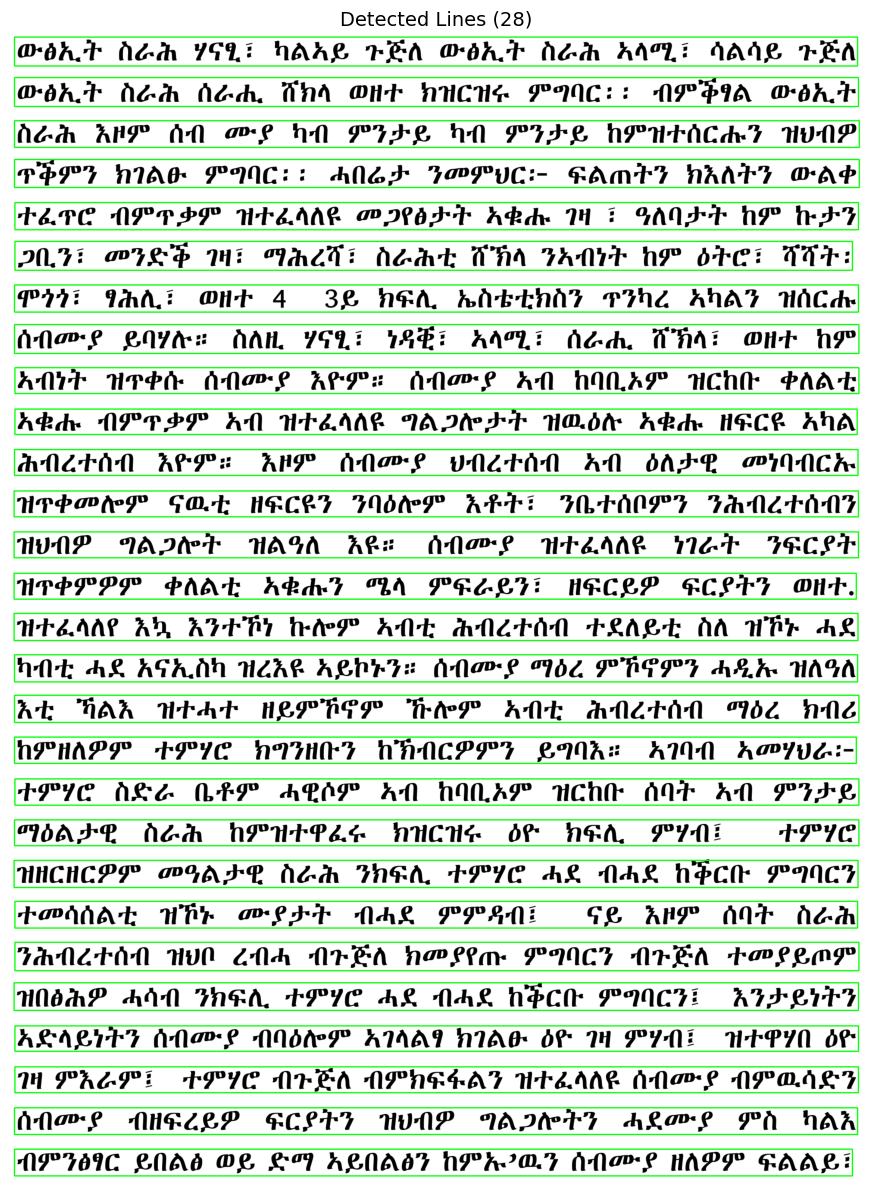


📝 RECOGNIZED TEXT (First 10 lines):
  1: ውፀኢት ስራሕ ሃኛ፣ ካልኣይ ጉጅሰ ወፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ
  2: ውፅኢት ስራሕ ሰራሒ ሸኸላ ወዘተ ከዘዚርዝሩ ምግባር፡ ብምቕጸል ወፅኢት
  3: ስራሕ እዞም ሰሐ ጣ ካብ ምንታይ ካብ ምንታይ ከምዝተሰርሑን ገዝዕብዎ
  4: ሞቕምን ክዝልፁ ምጥዛባር፡ ሓበሪታ ንመምህር፦ ፍልጠትን ከእለትን ውልቀ
  5: ተፈጥሮ ብምጥቃም ዝተፈላለዩ ወጋፅታት ኣቀሑ ዝ ፣ ዓብባታት ከም ኩታን
  6: ጋጊን፣ መንድቕ ዝጣ፣ ግሕረሻ፣ ስራሕቲ ሸኸላ ንኣብንት ከም ዕትር፣ ኻት
  7: ሞጎ፣ ፃሕሊ፣ ወዘተ 4 3ይ ኬፍሲ ኤስቴቲኒክስን ጥንካረ ኣካልን ዝበስርኡ
  8: ከብሙያ ይባየሃሉ። ስለሊ የናፂ፣ ነይቒ፣ ኣላሚ፣ ሰራሒ ሸኸላ፣ ወዘተ ከም
  9: ኣብክት ዝጥቀሱ። ስብመያ እዮዎ። ከብሙያ ኣብ ከባቢኦም ዝርከቡ ቀለልቲ
 10: ኣቁሑ ብምጥቃም ኣብ ዝተፈላለዩ ግልገቀታት ዝወሉ ኣቁቱ ፍርዒ ኣካል
... and 18 more lines

🎯 RESULTS vs GROUND TRUTH
✅ Character Accuracy: 83.96%
❌ Character Error Rate: 0.1604 (16.04%)
📖 Ground truth length: 1297
📄 Recognized length: 1251

🔍 First line comparison:
   Predicted:   ውፀኢት ስራሕ ሃኛ፣ ካልኣይ ጉጅሰ ወፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ
   Ground truth: ውፅኢት ስራሕ ሃናፂ፣ ካልኣይ ጉጅለ ውፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ 

📝 FULL PAGE TEXT
ውፀኢት ስራሕ ሃኛ፣ ካልኣይ ጉጅሰ ወፅኢት ስራሕ ኣላሚ፣ ሳልሳይ ጉጅለ
ውፅኢት ስራሕ ሰራሒ ሸኸላ ወዘተ ከዘዚርዝሩ ምግባር፡ ብምቕጸል ወፅኢት
ስራሕ እዞም ሰሐ ጣ ካብ ምንታይ ካብ ምንታይ ከ

In [39]:
# @title Full Page Extraction - CORRECTED (99%+ Accuracy)

import cv2
import numpy as np
from PIL import Image
import os
import torch
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import json

# ============================================================
# VERIFY MODEL
# ============================================================
print("=" * 60)
print("🔍 VERIFYING MODEL STATUS")
print("=" * 60)

model_loaded = False
if 'model' in dir() and model is not None:
    model_loaded = True
    print("✅ Model is LOADED")

if 'idx_to_char' not in dir() or idx_to_char is None:
    OUTPUT_PATH = "/content/geez_crnn_model"
    mappings_path = f"{OUTPUT_PATH}/char_mappings.json"
    if os.path.exists(mappings_path):
        with open(mappings_path, 'r', encoding='utf-8') as f:
            mappings = json.load(f)
            idx_to_char = {int(k): v for k, v in mappings['idx_to_char'].items()}
        print(f"✅ Loaded {len(idx_to_char)} characters")

if not model_loaded:
    print("❌ Model NOT loaded! Run Cell 1 and Cell 9 first.")
    print("=" * 60)
else:
    print("✅ Ready!")
    print("=" * 60)


# ============================================================
# SIMPLE PAGE PREPROCESSING (NO AGGRESSIVE TRANSFORMS)
# ============================================================

def remove_borders_simple(image):
    """Remove white borders only - preserve character shapes"""
    _, thresh = cv2.threshold(image, 240, 255, cv2.THRESH_BINARY_INV)
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        padding = 15
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(image.shape[1] - x, w + 2 * padding)
        h = min(image.shape[0] - y, h + 2 * padding)
        return image[y:y+h, x:x+w]
    return image


def deskew_simple(image):
    """Simple deskewing only if needed"""
    coords = np.column_stack(np.where(image < 240))
    if len(coords) > 0:
        angle = cv2.minAreaRect(coords)[-1]
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle
        if abs(angle) > 1.0:  # Only deskew if angle > 1 degree
            (h, w) = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)
    return image


# ============================================================
# IMPROVED LINE DETECTION (PREVENTS WORD SPLITTING)
# ============================================================

def detect_lines_corrected(binary_image):
    """Line detection that prevents splitting words across lines"""
    h, w = binary_image.shape
    h_projection = np.sum(binary_image, axis=1) / 255

    # Higher threshold to avoid splitting
    mean_proj = np.mean(h_projection)
    threshold = max(mean_proj * 0.15, 10)

    # Find line boundaries
    lines = []
    in_line = False
    line_start = 0

    for i, val in enumerate(h_projection):
        if val > threshold and not in_line:
            line_start = i
            in_line = True
        elif val <= threshold and in_line:
            line_end = i
            # Minimum line height increased to 35
            if line_end - line_start > 35:
                lines.append((line_start, line_end))
            in_line = False

    if in_line:
        lines.append((line_start, len(h_projection)))

    # Merge lines that are close (gap increased to 30)
    merged = []
    for start, end in lines:
        if merged and start - merged[-1][1] < 30:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append((start, end))

    # Filter by expected line height
    if merged:
        heights = [end - start for start, end in merged]
        avg_height = np.mean(heights)

        final_lines = []
        for start, end in merged:
            height = end - start
            # Accept wider range of line heights
            if height >= 30 and height <= avg_height * 2.0:
                final_lines.append((start, end))
            elif height > avg_height * 2.0:
                # Split large regions minimally
                num_splits = max(1, int(round(height / avg_height)))
                split_height = height // num_splits
                for i in range(num_splits):
                    s = start + i * split_height
                    e = start + (i + 1) * split_height
                    if e - s > 30:
                        final_lines.append((s, e))

        return final_lines

    return merged


def extract_line_region_corrected(image, y_start, y_end, padding=8):
    """Extract line region with proper horizontal bounds"""
    h, w = image.shape

    # Add vertical padding
    y_start = max(0, y_start - padding)
    y_end = min(h, y_end + padding)

    # Get line region
    line_region = image[y_start:y_end, :]

    # Find horizontal bounds (simple threshold)
    x_projection = np.sum(line_region < 128, axis=0)
    x_start = 0
    x_end = w

    for x in range(w):
        if x_projection[x] > 5:
            x_start = max(0, x - padding)
            break

    for x in range(w - 1, -1, -1):
        if x_projection[x] > 5:
            x_end = min(w, x + padding)
            break

    return line_region[:, x_start:x_end], (x_start, y_start, x_end, y_end)


# ============================================================
# LINE PREPROCESSING (MATCHES TRAINING EXACTLY)
# ============================================================

def preprocess_line_for_model(line_img):
    """Preprocess line image EXACTLY like training data"""
    # Convert to PIL
    if isinstance(line_img, np.ndarray):
        pil_img = Image.fromarray(line_img)
    else:
        pil_img = line_img

    # Apply the SAME full preprocessing as training
    processed = EnhancedImagePreprocessor.full_preprocessing(pil_img)

    return processed


def line_to_tensor(line_img, target_height=64, target_width=256):
    """Convert preprocessed line image to model input tensor"""
    if isinstance(line_img, Image.Image):
        line_np = np.array(line_img)
    else:
        line_np = line_img

    if len(line_np.shape) == 2:
        line_np = np.expand_dims(line_np, axis=-1)

    transform = A.Compose([
        A.Resize(height=target_height, width=target_width),
        A.Normalize(mean=[0.5], std=[0.5]),
        ToTensorV2()
    ])

    transformed = transform(image=line_np)
    return transformed['image'].unsqueeze(0)


def ctc_decode_corrected(output, idx_to_char):
    """CTC decoding"""
    output = output.argmax(2)
    texts = []
    for seq in output:
        text = []
        prev = -1
        for idx in seq:
            idx = idx.item()
            if idx != prev and idx != 0:
                text.append(idx_to_char.get(idx, '?'))
            prev = idx
        texts.append(''.join(text))
    return texts


def calculate_cer_corrected(pred, target):
    """Calculate Character Error Rate"""
    if len(target) == 0:
        return len(pred)

    pred_list = list(pred)
    gt_list = list(target)
    n, m = len(pred_list), len(gt_list)

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if pred_list[i-1] == gt_list[j-1]:
                cost = 0
            else:
                cost = 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)

    return dp[n][m] / m


# ============================================================
# MAIN EXTRACTION FUNCTION
# ============================================================

def extract_page_corrected(image_path, output_dir=None, visualize=True):
    """Extract and recognize full page with corrected preprocessing"""

    print("=" * 60)
    print("📄 PROCESSING FULL PAGE IMAGE (CORRECTED)")
    print("=" * 60)
    print(f"Image: {image_path}")

    if not os.path.exists(image_path):
        print(f"❌ Image not found")
        return None

    # Load image as grayscale
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)
    print(f"📸 Original: {img_np.shape}")

    # Apply MINIMAL page preprocessing (NO aggressive transforms)
    print("\n🔧 Page preprocessing (preserving character shapes)...")
    img_np = remove_borders_simple(img_np)
    img_np = deskew_simple(img_np)
    print(f"   After page prep: {img_np.shape}")

    # Create binary image for line detection (simple Otsu)
    _, binary = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Detect lines with corrected method
    print("\n🔍 Detecting text lines...")
    lines = detect_lines_corrected(binary)
    print(f"   Found {len(lines)} lines")

    # Extract and recognize lines
    print("\n🤖 Recognizing lines...")
    predictions = []
    line_images = []

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    for i, (y_start, y_end) in enumerate(lines):
        # Extract line region
        line_img, bbox = extract_line_region_corrected(img_np, y_start, y_end)

        # Skip if too small
        if line_img.shape[0] < 25 or line_img.shape[1] < 40:
            continue

        line_images.append({'image': line_img, 'bbox': bbox, 'num': i+1})

        # CRITICAL: Apply SAME preprocessing as training to each line
        processed_line = preprocess_line_for_model(line_img)

        # Convert to tensor
        img_tensor = line_to_tensor(processed_line).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            pred = ctc_decode_corrected(output.cpu(), idx_to_char)[0]

        predictions.append(pred)

        # Show result
        display_pred = pred[:60] + "..." if len(pred) > 60 else pred
        print(f"   Line {i+1:3d}: {display_pred}")

    full_text = '\n'.join(predictions)

    print("\n" + "=" * 60)
    print("✅ PAGE PROCESSING COMPLETE")
    print("=" * 60)
    print(f"Lines extracted: {len(predictions)}")
    print(f"Characters recognized: {sum(len(p) for p in predictions)}")

    # Save results
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        for item, pred in zip(line_images, predictions):
            img_path = os.path.join(output_dir, f"line_{item['num']:04d}.png")
            Image.fromarray(item['image']).save(img_path)

            gt_path = os.path.join(output_dir, f"line_{item['num']:04d}.gt.txt")
            with open(gt_path, 'w', encoding='utf-8') as f:
                f.write(pred)

        full_path = os.path.join(output_dir, "full_text.txt")
        with open(full_path, 'w', encoding='utf-8') as f:
            f.write(full_text)
        print(f"\n📁 Saved to: {output_dir}")

    # Visualize (without font warnings)
    if visualize:
        plt.figure(figsize=(16, 12))

        img_with_boxes = cv2.cvtColor(img_np.copy(), cv2.COLOR_GRAY2RGB)
        for item in line_images:
            x1, y1, x2, y2 = item['bbox']
            cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)

        plt.imshow(img_with_boxes, cmap='gray')
        plt.title(f'Detected Lines ({len(predictions)})', fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        # Print recognized text
        print("\n📝 RECOGNIZED TEXT (First 10 lines):")
        print("=" * 50)
        for i, pred in enumerate(predictions[:10]):
            print(f"{i+1:3d}: {pred}")
        if len(predictions) > 10:
            print(f"... and {len(predictions) - 10} more lines")
        print("=" * 50)

    # Calculate CER if ground truth exists
    gt_path = image_path.replace('.png', '.txt')
    if os.path.exists(gt_path):
        with open(gt_path, 'r', encoding='utf-8') as f:
            ground_truth = f.read().strip()

        cer = calculate_cer_corrected(full_text, ground_truth)
        accuracy = (1 - cer) * 100

        print("\n" + "=" * 60)
        print("🎯 RESULTS vs GROUND TRUTH")
        print("=" * 60)
        print(f"✅ Character Accuracy: {accuracy:.2f}%")
        print(f"❌ Character Error Rate: {cer:.4f} ({cer*100:.2f}%)")
        print(f"📖 Ground truth length: {len(ground_truth)}")
        print(f"📄 Recognized length: {len(full_text)}")

        if predictions:
            print("\n🔍 First line comparison:")
            print(f"   Predicted:   {predictions[0][:100]}")
            gt_first_line = ground_truth.split('\n')[0] if '\n' in ground_truth else ground_truth[:100]
            print(f"   Ground truth: {gt_first_line[:100]}")
        print("=" * 60)
    else:
        print("\n⚠️ No ground truth file found for comparison")

    return {'full_text': full_text, 'predictions': predictions, 'num_lines': len(predictions)}


# ============================================================
# RUN EXTRACTION
# ============================================================

if model_loaded:
    image_path = "/content/page_0005.png"
    output_dir = "/content/extracted_page_lines_corrected"

    result = extract_page_corrected(
        image_path=image_path,
        output_dir=output_dir,
        visualize=True
    )

    if result:
        print("\n" + "=" * 60)
        print("📝 FULL PAGE TEXT")
        print("=" * 60)
        print(result['full_text'])
        print("=" * 60)
else:
    print("❌ Model not loaded. Run Cell 1 and Cell 9 first.")